# FAVAR Model for WTI Direction Forecasting

This notebook trains Factor-Augmented Vector Autoregression (FAVAR) models to predict the next-day direction of WTI crude oil prices. I compare several feature specifications: a baseline macro/price model, a CFTC/COT-augmented model, an HMM regime-feature model, and a regime-specific modeling approach.

The FAVAR approach first reduces the high-dimensional predictor set into a smaller number of latent factors using PCA. A VAR model is then fit to the factor-augmented state, and the forecasted return is converted into an estimated probability of an upward WTI move. This makes FAVAR different from the supervised classifiers because it models the joint time-series dynamics of the latent factor state rather than directly learning a nonlinear classification rule.

It's important to note that everything until the "Final Runs" are not included in the paper due to the dates changing based on COT data. I used the same tuned hyperparameters on the final runs that I found in the prelimary runs.

In [189]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from statsmodels.tsa.api import VAR
from sklearn.decomposition import PCA
from scipy.stats import t, norm, jarque_bera, shapiro, normaltest
import os
import scipy.stats as stats


## 1. Load Chronological Train, Validation, and Test Splits

The train, validation, and test files were created using chronological splits. This is necessary for a time-series forecasting problem because shuffling observations would allow future market conditions to influence earlier training observations.

I recompute log returns from WTI prices so that the FAVAR return forecasts and trading-strategy evaluation use a consistent realized-return series.

In [128]:
train_df = pd.read_csv("train_final.csv")
val_df = pd.read_csv("val_final.csv")
test_df = pd.read_csv("test_final.csv")

for df in [train_df, val_df, test_df]:
    df["returns"] = np.log(df["Price"]).diff()
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)

for df in [train_df, val_df, test_df]:
    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)
    df.reset_index(drop=True, inplace=True)

print(train_df.shape, val_df.shape, test_df.shape)
print(train_df["Date"].min(), train_df["Date"].max())
print(val_df["Date"].min(), val_df["Date"].max())
print(test_df["Date"].min(), test_df["Date"].max())

(1742, 50) (528, 50) (474, 50)
2015-05-24 00:00:00 2021-12-31 00:00:00
2022-01-04 00:00:00 2023-12-29 00:00:00
2024-01-03 00:00:00 2025-10-31 00:00:00


## 2. Inspect the Full Modeling Sample

I combine the train, validation, and test splits only for exploratory diagnostics. Model fitting and scaling are still performed using the appropriate train-only or train-validation-only windows later in the notebook.

In [129]:
full_df = pd.concat([train_df, val_df, test_df])
full_df

,Date,RPI,W875RX1,CMRMTSPLx,IPFPNSS,USWTRADE,USTRADE,BUSLOANS,CONSPI,S&P 500,...,momentum_20,vol_60,drawdown,trend,regime_prob_0,regime_prob_1,regime_prob_2,regime,Price,Target
0,2015-05-24,15833.624,13080.5,1321167.0,100.8979,5778.7,15522.1,1847.9368,161.578916,2094.86,...,0.051413,0.026567,-0.016576,7.6732,1.879868e-22,5.423862e-07,9.999995e-01,2,59.92,0
1,2015-05-25,15833.624,13080.5,1321167.0,100.8979,5778.7,15522.1,1847.9368,161.578916,2094.86,...,0.048896,0.026497,-0.017725,7.7021,1.825025e-22,5.469315e-07,9.999995e-01,2,59.85,0
2,2015-05-26,15833.624,13080.5,1321167.0,100.8979,5778.7,15522.1,1847.9368,161.578916,2094.86,...,-0.009389,0.026753,-0.047596,7.5779,9.756554e-23,4.989855e-07,9.999995e-01,2,58.03,0
3,2015-05-27,15833.624,13080.5,1321167.0,100.8979,5778.7,15522.1,1847.9368,161.578916,2094.86,...,-0.035553,0.026698,-0.056130,7.3575,8.207857e-23,4.845910e-07,9.999995e-01,2,57.51,1
4,2015-05-28,15833.624,13080.5,1321167.0,100.8979,5778.7,15522.1,1847.9368,161.578916,2094.86,...,-0.024852,0.026494,-0.053340,7.1661,8.829575e-23,4.874758e-07,9.999995e-01,2,57.68,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469,2025-10-27,20603.322,16654.3,1551287.0,97.7772,6165.9,15605.2,2693.7764,143.127140,6584.02,...,-0.033727,0.016566,-0.067103,-4.5104,2.051037e-26,1.000000e+00,1.066759e-18,1,61.31,0
470,2025-10-28,20603.322,16654.3,1551287.0,97.7772,6165.9,15605.2,2693.7764,143.127140,6584.02,...,-0.035594,0.016664,-0.084753,-4.5539,1.674085e-26,1.000000e+00,1.086546e-18,1,60.15,1
471,2025-10-29,20603.322,16654.3,1551287.0,97.7772,6165.9,15605.2,2693.7764,143.127140,6584.02,...,-0.021042,0.016663,-0.079732,-4.5573,2.111523e-26,1.000000e+00,1.094233e-18,1,60.48,1
472,2025-10-30,20603.322,16654.3,1551287.0,97.7772,6165.9,15605.2,2693.7764,143.127140,6584.02,...,0.001488,0.016666,-0.078363,-4.4456,2.444037e-26,1.000000e+00,1.084343e-18,1,60.57,1


## 3. Examine the Return Distribution

Before converting FAVAR return forecasts into probabilities, I inspect the empirical distribution of WTI log returns. This matters because oil returns can be heavy-tailed, so a normal distribution may understate the probability of large moves. For that reason, I compare normal and Student-t probability mappings during tuning.

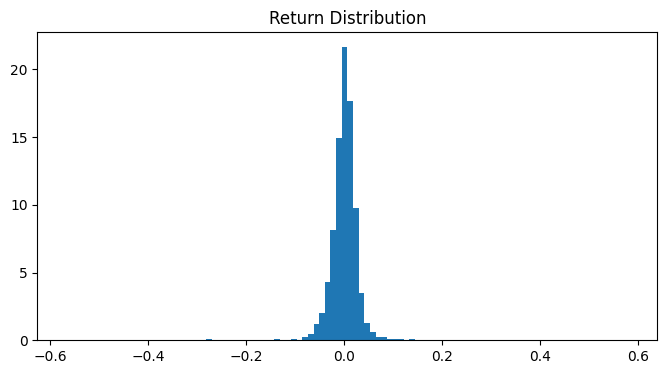

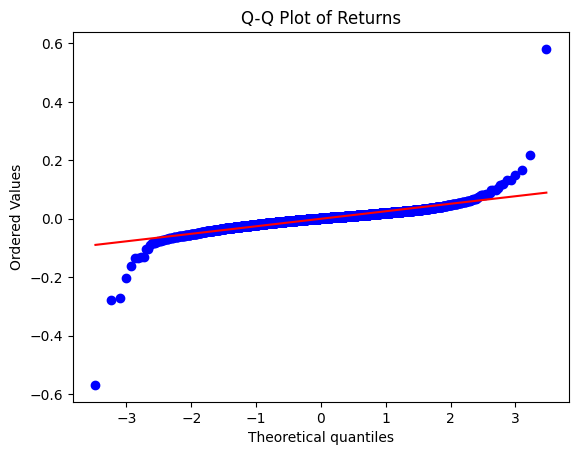

Skew: -0.3738201615409268
Kurtosis: 103.26957207105858
Jarque-Bera p-value: 0.0
D'Agostino normality p-value: 1.2225781727826977e-253


In [ ]:
# Test whether daily WTI returns appear normally distributed.
# Heavy tails motivate using a Student-t probability mapping later.
returns = full_df["returns"].dropna()

plt.figure(figsize=(8, 4))
plt.hist(returns, bins=100, density=True)
plt.title("Return Distribution")
plt.show()

stats.probplot(returns, dist="norm", plot=plt)
plt.title("Q-Q Plot of Returns")
plt.show()

print("Skew:", returns.skew())
print("Kurtosis:", returns.kurtosis())

jb_stat, jb_p = jarque_bera(returns)
print("Jarque-Bera p-value:", jb_p)

nt_stat, nt_p = normaltest(returns)
print("D'Agostino normality p-value:", nt_p)

## 4. Define Baseline FAVAR Feature Set

The target variable is the next-day WTI direction. Non-predictive columns such as date, price, realized returns, and the target label are excluded from the predictor matrix. Regime labels and regime probabilities are also excluded from the baseline model so it can be compared fairly against the later regime-enhanced specifications.

The FAVAR model uses the remaining predictors to estimate latent factors. The realized return is then appended to the factor state so the VAR model can forecast the return component.

In [130]:
target_col = "Target"

baseline_exclude_cols = [
    "Date",
    "Price",
    "returns",
    "Target",
    "regime",
    "regime_prob_0",
    "regime_prob_1",
    "regime_prob_2"
]

favar_feature_cols = [c for c in train_df.columns if c not in baseline_exclude_cols]

print("FAVAR baseline feature count:", len(favar_feature_cols))
print(favar_feature_cols)

FAVAR baseline feature count: 42
['RPI', 'W875RX1', 'CMRMTSPLx', 'IPFPNSS', 'USWTRADE', 'USTRADE', 'BUSLOANS', 'CONSPI', 'S&P 500', 'S&P PE ratio', 'FEDFUNDS', 'TB3MS', 'TB6MS', 'GS1', 'GS5', 'GS10', 'AAA', 'BAA', 'TB3SMFFM', 'TB6SMFFM', 'T1YFFM', 'T5YFFM', 'T10YFFM', 'AAAFFM', 'BAAFFM', 'EXSZUSx', 'EXJPUSx', 'EXUSUKx', 'EXCAUSx', 'PPICMM', 'UMCSENTx', 'net_position', 'net_position_pct', 'flow', 'long_short_ratio', 'Open_Interest_All', 'oi_change', 'vol_20', 'momentum_20', 'vol_60', 'drawdown', 'trend']


## 5. Build the FAVAR State

This helper standardizes the predictor variables using the training set only, applies PCA to extract latent factors, and appends the realized WTI return as the final state variable. The resulting matrix is the state used by the VAR model.

Scaling and PCA are fit only on the training data, then applied to validation or test data. This avoids leakage from future observations into the factor construction step.

In [23]:
def build_favar_state(train_df, eval_df, feature_cols, k):
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(train_df[feature_cols])
    X_eval_scaled = scaler.transform(eval_df[feature_cols])

    pca = PCA(n_components=k)

    train_factors = pca.fit_transform(X_train_scaled)
    eval_factors = pca.transform(X_eval_scaled)

    factor_cols = [f"factor_{i}" for i in range(1, k + 1)]

    train_factor_df = pd.DataFrame(train_factors, columns=factor_cols)
    eval_factor_df = pd.DataFrame(eval_factors, columns=factor_cols)

    train_z = pd.concat(
        [
            train_df[["Price"]].reset_index(drop=True),
            train_factor_df.reset_index(drop=True)
        ],
        axis=1
    )

    eval_z = pd.concat(
        [
            eval_df[["Price"]].reset_index(drop=True),
            eval_factor_df.reset_index(drop=True)
        ],
        axis=1
    )

    return train_z, eval_z, scaler, pca

## 6. Convert Forecasted Returns into Up-Move Probabilities

The VAR model produces a forecasted return rather than a direct class probability. To evaluate the model as a directional classifier and use it in a probability-based trading strategy, I convert the forecasted return into the probability that the next return is positive.

I compare a normal distribution and a Student-t distribution. The Student-t distribution is useful because daily oil returns can be heavy-tailed, so the Student-t mapping is less sensitive to extreme observations than a strictly normal assumption.

In [24]:
def favar_prob_up(forecast_return, rolling_vol, method="student_t", t_df=5):
    rolling_vol = max(float(rolling_vol), 1e-6)
    z = forecast_return / rolling_vol

    if method == "student_t":
        return t.cdf(z, df=t_df)

    if method == "normal":
        return norm.cdf(z)

    raise ValueError("method must be 'student_t' or 'normal'")

## 7. Rolling VAR Forecast Function

This helper performs a rolling one-step-ahead forecast. At each validation or test date, the VAR model is fit using the available history up to that point, then used to forecast the next state. The return component of the forecasted state is converted into an up-move probability.

After each forecast, the realized observation is added to the history. This creates a realistic expanding-window evaluation where future observations are not used before they occur.

In [25]:
def rolling_var_forecast_with_probs(
    train_z,
    eval_z,
    eval_meta,
    p,
    vol_window=20,
    method="student_t",
    t_df=5
):
    history = train_z.copy().reset_index(drop=True)
    eval_z = eval_z.copy().reset_index(drop=True)
    eval_meta = eval_meta.copy().reset_index(drop=True)

    pred_price = []
    forecast_return = []
    prob_up = []
    pred = []

    for i in range(len(eval_z)):
        model = VAR(history)
        fitted = model.fit(maxlags=p, trend="c")
        lag_order = fitted.k_ar

        forecast = fitted.forecast(history.values[-lag_order:], steps=1)[0]
        price_forecast = forecast[0]

        previous_price = history["Price"].iloc[-1]
        ret_hat = (price_forecast - previous_price) / previous_price

        rolling_vol = eval_meta["returns"].iloc[:i].tail(vol_window).std()

        if i < vol_window or pd.isna(rolling_vol) or rolling_vol == 0:
            rolling_vol = history["Price"].pct_change().dropna().tail(vol_window).std()

        p_up = favar_prob_up(
            forecast_return=ret_hat,
            rolling_vol=rolling_vol,
            method=method,
            t_df=t_df
        )

        pred_price.append(price_forecast)
        forecast_return.append(ret_hat)
        prob_up.append(p_up)
        pred.append(int(p_up >= 0.5))

        history = pd.concat(
            [history, eval_z.iloc[[i]]],
            axis=0
        ).reset_index(drop=True)

    out = eval_meta[["Date", "Price", "returns", "vol_20", "Target"]].copy()

    out["pred_price"] = pred_price
    out["forecast_return"] = forecast_return
    out["prob_up"] = prob_up
    out["pred"] = pred
    out["model"] = "favar"
    out["version"] = "baseline"
    out["split"] = "unknown"

    return out

In [ ]:
prob_method = "student_t"   # or "normal"
t_df = 5
vol_window = 20

## 8. Tune the Baseline FAVAR

The FAVAR tuning loop searches over the number of PCA factors, VAR lag length, probability mapping method, and Student-t degrees of freedom. Validation ROC-AUC is used as the primary model-selection metric because the trading strategy depends on probability rankings rather than only hard class predictions.

In [45]:
factor_candidates = [2, 3, 4, 5, 6, 7, 8, 9, 10]
lag_candidates = [1, 2, 3, 4, 5, 6]
method_candidates = ["student_t", "normal"]
t_df_candidates = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

favar_results = []

for k in factor_candidates:
    train_z, val_z, scaler_k, pca_k = build_favar_state(
        train_df,
        val_df,
        favar_feature_cols,
        k
    )

    for p in lag_candidates:
        for method in method_candidates:

            if method == "normal":
                df_options = [None]
            else:
                df_options = t_df_candidates

            for t_df_val in df_options:
                print(f"Running k={k}, p={p}, method={method}, t_df={t_df_val}")

                try:
                    val_preds_tmp = rolling_var_forecast_with_probs(
                        train_z=train_z,
                        eval_z=val_z,
                        eval_meta=val_df,
                        p=p,
                        vol_window=20,
                        method=method,
                        t_df=5 if t_df_val is None else t_df_val
                    )

                    acc = accuracy_score(
                        val_preds_tmp["Target"],
                        val_preds_tmp["pred"]
                    )

                    try:
                        auc = roc_auc_score(
                            val_preds_tmp["Target"],
                            val_preds_tmp["prob_up"]
                        )
                    except ValueError:
                        auc = np.nan

                    favar_results.append({
                        "k": k,
                        "p": p,
                        "method": method,
                        "t_df": t_df_val,
                        "val_accuracy": acc,
                        "val_auc": auc,
                        "prob_mean": val_preds_tmp["prob_up"].mean(),
                        "prob_std": val_preds_tmp["prob_up"].std()
                    })

                except Exception as e:
                    print(f"Failed k={k}, p={p}, method={method}, t_df={t_df_val}: {e}")

                    favar_results.append({
                        "k": k,
                        "p": p,
                        "method": method,
                        "t_df": t_df_val,
                        "val_accuracy": np.nan,
                        "val_auc": np.nan,
                        "prob_mean": np.nan,
                        "prob_std": np.nan
                    })

favar_results_df = pd.DataFrame(favar_results).sort_values(
    by="val_auc",
    ascending=False
).reset_index(drop=True)

favar_results_df.head(20)

Running k=2, p=1, method=student_t, t_df=1
Running k=2, p=1, method=student_t, t_df=2
Running k=2, p=1, method=student_t, t_df=3
Running k=2, p=1, method=student_t, t_df=4
Running k=2, p=1, method=student_t, t_df=5
Running k=2, p=1, method=student_t, t_df=6
Running k=2, p=1, method=student_t, t_df=7
Running k=2, p=1, method=student_t, t_df=8
Running k=2, p=1, method=student_t, t_df=9
Running k=2, p=1, method=student_t, t_df=10
Running k=2, p=1, method=normal, t_df=None
Running k=2, p=2, method=student_t, t_df=1
Running k=2, p=2, method=student_t, t_df=2
Running k=2, p=2, method=student_t, t_df=3
Running k=2, p=2, method=student_t, t_df=4
Running k=2, p=2, method=student_t, t_df=5
Running k=2, p=2, method=student_t, t_df=6
Running k=2, p=2, method=student_t, t_df=7
Running k=2, p=2, method=student_t, t_df=8
Running k=2, p=2, method=student_t, t_df=9
Running k=2, p=2, method=student_t, t_df=10
Running k=2, p=2, method=normal, t_df=None
Running k=2, p=3, method=student_t, t_df=1
Running k

,k,p,method,t_df,val_accuracy,val_auc,prob_mean,prob_std
0,2,3,student_t,6.0,0.577652,0.622048,0.482090,0.045470
1,2,3,student_t,10.0,0.577652,0.622048,0.481772,0.046320
2,2,3,student_t,8.0,0.577652,0.622048,0.481892,0.045998
3,2,3,student_t,7.0,0.577652,0.622048,0.481977,0.045771
4,2,3,normal,NaN,0.577652,0.622048,0.481280,0.047636
5,2,3,student_t,5.0,0.577652,0.622048,0.482245,0.045055
6,2,3,student_t,4.0,0.577652,0.622048,0.482475,0.044443
7,2,3,student_t,3.0,0.577652,0.622048,0.482845,0.043458
8,2,3,student_t,2.0,0.577652,0.622048,0.483539,0.041613
9,2,3,student_t,1.0,0.577652,0.622048,0.485282,0.037000


## 9. Select the Baseline FAVAR Specification

The best baseline specification is selected using validation ROC-AUC. I store the selected number of factors, lag order, probability mapping method, and Student-t degrees of freedom for the final validation and test forecasts.

In [46]:
best_row = favar_results_df.dropna(subset=["val_auc"]).iloc[0]

best_k = int(best_row["k"])
best_p = int(best_row["p"])
best_method = best_row["method"]
best_t_df = 5 if pd.isna(best_row["t_df"]) else int(best_row["t_df"])

print("Best k:", best_k)
print("Best p:", best_p)
print("Best method:", best_method)
print("Best t_df:", best_t_df)

best_row

Best k: 2
Best p: 3
Best method: student_t
Best t_df: 6


k                       2
p                       3
method          student_t
t_df                  6.0
val_accuracy     0.577652
val_auc          0.622048
prob_mean         0.48209
prob_std          0.04547
Name: 0, dtype: object

## 10. Generate Baseline FAVAR Predictions

Using the selected FAVAR specification, I generate validation, training, and test predictions. The validation and test forecasts use an expanding-window procedure, while the training predictions use a rolling in-sample procedure after an initial history window.

In [47]:
train_z, val_z, favar_scaler, favar_pca = build_favar_state(
    train_df,
    val_df,
    favar_feature_cols,
    best_k
)

favar_val_preds = rolling_var_forecast_with_probs(
    train_z=train_z,
    eval_z=val_z,
    eval_meta=val_df,
    p=best_p,
    vol_window=vol_window,
    method=prob_method,
    t_df=t_df
)

favar_val_preds["split"] = "val"
favar_val_preds["model"] = "favar"
favar_val_preds["version"] = "baseline"

In [48]:
def rolling_var_train_predictions_with_probs(
    train_z,
    train_meta,
    p,
    initial_window=250,
    vol_window=20,
    method="student_t",
    t_df=5
):
    preds = []

    for i in range(initial_window, len(train_z)):
        history = train_z.iloc[:i].copy().reset_index(drop=True)
        current_z = train_z.iloc[[i]].copy().reset_index(drop=True)
        current_meta = train_meta.iloc[[i]].copy().reset_index(drop=True)

        pred_i = rolling_var_forecast_with_probs(
            train_z=history,
            eval_z=current_z,
            eval_meta=current_meta,
            p=p,
            vol_window=vol_window,
            method=method,
            t_df=t_df
        )

        preds.append(pred_i)

    out = pd.concat(preds, ignore_index=True)
    out["split"] = "train"
    out["model"] = "favar"
    out["version"] = "baseline"

    return out

In [49]:
favar_train_preds = rolling_var_train_predictions_with_probs(
    train_z=train_z,
    train_meta=train_df,
    p=best_p,
    initial_window=250,
    vol_window=vol_window,
    method=prob_method,
    t_df=t_df
)

In [50]:
train_z_test, test_z, _, _ = build_favar_state(
    train_df,
    test_df,
    favar_feature_cols,
    best_k
)

favar_test_preds = rolling_var_forecast_with_probs(
    train_z=train_z_test,
    eval_z=test_z,
    eval_meta=test_df,
    p=best_p,
    vol_window=vol_window,
    method=prob_method,
    t_df=t_df
)

favar_test_preds["split"] = "test"
favar_test_preds["model"] = "favar"
favar_test_preds["version"] = "baseline"

## 11. Strategy Metric Helper

This helper computes trading-strategy performance metrics, including total return, CAGR, annualized volatility, Sharpe ratio, maximum drawdown, average position size, and turnover.

In [152]:
def strategy_metrics(df, return_col, periods_per_year=252):
    data = df.dropna(subset=[return_col]).copy()

    ret = data[return_col]

    total_return = (1 + ret).prod() - 1
    n_years = len(ret) / periods_per_year

    cagr = (1 + total_return) ** (1 / n_years) - 1 if n_years > 0 else np.nan

    ann_vol = ret.std() * np.sqrt(periods_per_year)
    ann_return = ret.mean() * periods_per_year

    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    wealth = (1 + ret).cumprod()
    peak = wealth.cummax()
    drawdown = wealth / peak - 1
    max_drawdown = drawdown.min()

    if return_col == "buy_hold_return":
        avg_position = 1.0
        avg_abs_position = 1.0
        avg_turnover = 0.0
    else:
        avg_position = df["position"].mean()
        avg_abs_position = df["position"].abs().mean()
        avg_turnover = df["turnover"].mean()

    return {
        "Total Return": total_return,
        "CAGR": cagr,
        "Annual Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_drawdown,
        "Avg Position": avg_position,
        "Avg Abs Position": avg_abs_position,
        "Avg Turnover": avg_turnover,
    }

## 12. Convert FAVAR Probabilities into Trading Positions

This function translates predicted up-move probabilities into daily trading positions. Probabilities above 0.50 create long exposure and probabilities below 0.50 create short exposure. The position is volatility-scaled using rolling 20-day volatility and clipped between -1 and 1.

Strategy returns use the previous day's position multiplied by the current day's realized return, which avoids look-ahead bias.

This is still the toy trading strategy

In [52]:
def apply_probability_vol_strategy(
    preds,
    target_annual_vol=0.15,
    vol_col="vol_20",
    transaction_cost=0.0005,
    vol_floor=0.005,
    alpha=1.0,
    beta=1.0,
    gamma=1.0
):
    df = preds.copy()

    raw_signal = 2.5 * df["prob_up"] - 1

    raw_signal = np.where(
        raw_signal >= 0,
        alpha * raw_signal,
        beta * raw_signal
    )

    raw_signal = np.sign(raw_signal) * (np.abs(raw_signal) ** gamma)

    target_daily_vol = target_annual_vol / np.sqrt(252)
    adjusted_vol = df[vol_col].clip(lower=vol_floor)

    df["position"] = raw_signal * (target_daily_vol / adjusted_vol)
    df["position"] = df["position"].clip(-1, 1)

    df["turnover"] = (df["position"] - df["position"].shift(1)).abs()

    df["gross_strategy_return"] = df["position"].shift(1) * df["returns"]
    df["net_strategy_return"] = df["gross_strategy_return"] - transaction_cost * df["turnover"]

    df["buy_hold_return"] = df["returns"]

    return df

## 13. Save Baseline FAVAR Predictions

The baseline FAVAR predictions are saved for later comparison across model versions and for trading-strategy evaluation.

In [53]:
os.makedirs("results/predictions", exist_ok=True)

favar_train_preds.to_csv(
    "results/predictions/favar_baseline_train_predictions.csv",
    index=False
)

favar_val_preds.to_csv(
    "results/predictions/favar_baseline_val_predictions.csv",
    index=False
)

favar_test_preds.to_csv(
    "results/predictions/favar_baseline_test_predictions.csv",
    index=False
)

The summary below checks the distribution of FAVAR validation predicted probabilities and forecasted returns.

In [54]:
favar_val_preds[
    ["prob_up", "pred", "Target", "returns", "vol_20", "forecast_return"]
].describe()

,prob_up,pred,Target,returns,vol_20,forecast_return
count,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000
mean,0.482245,0.323864,0.530303,-0.000103,0.024159,-0.001041
std,0.045055,0.468392,0.499554,0.025630,0.008671,0.002829
min,0.231563,0.000000,0.000000,-0.134360,0.008609,-0.018334
25%,0.461760,0.000000,0.000000,-0.015055,0.018637,-0.002251
50%,0.484453,0.000000,1.000000,0.001782,0.022686,-0.000932
75%,0.508760,1.000000,1.000000,0.016680,0.027254,0.000476
max,0.624857,1.000000,1.000000,0.082612,0.055159,0.010004


The histograms below show the distribution of predicted upward-move probabilities for the baseline FAVAR model.

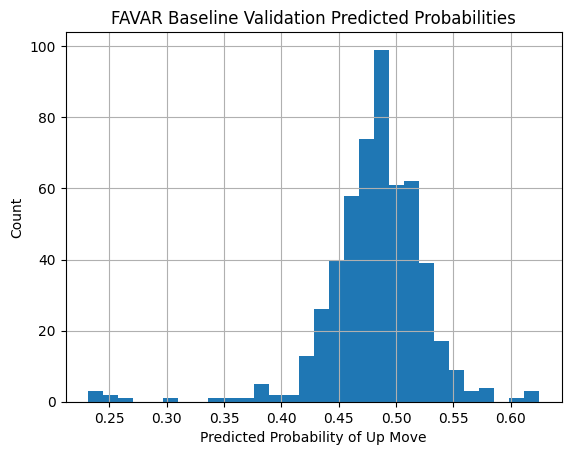

In [55]:
plt.hist(favar_val_preds["prob_up"], bins=30)
plt.title("FAVAR Baseline Validation Predicted Probabilities")
plt.xlabel("Predicted Probability of Up Move")
plt.ylabel("Count")
plt.grid(True)
plt.show()

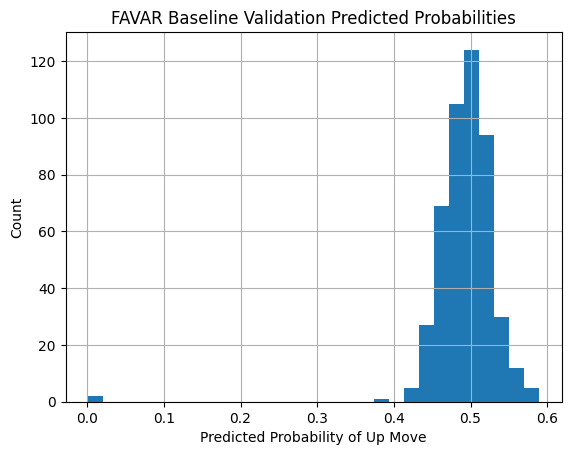

In [56]:
plt.hist(favar_test_preds["prob_up"], bins=30)
plt.title("FAVAR Baseline Validation Predicted Probabilities")
plt.xlabel("Predicted Probability of Up Move")
plt.ylabel("Count")
plt.grid(True)
plt.show()

## 14. Baseline Classification Evaluation

The classification metrics evaluate directional forecasting performance. Accuracy measures the overall fraction of correct up/down predictions, precision measures how often predicted up moves were correct, recall measures how many actual up moves were captured, F1 balances precision and recall, and ROC-AUC evaluates the ranking quality of predicted probabilities.

In [57]:
def classification_report_simple(preds):
    y_true = preds["Target"]
    y_pred = preds["pred"]
    prob = preds["prob_up"]

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, prob),
        "confusion_matrix": confusion_matrix(y_true, y_pred)
    }

In [58]:
classification_report_simple(favar_val_preds)

{'accuracy': 0.5776515151515151,
 'precision': 0.6666666666666666,
 'recall': 0.40714285714285714,
 'f1': 0.5055432372505543,
 'roc_auc': 0.6220478110599079,
 'confusion_matrix': array([[191,  57],
        [166, 114]], dtype=int64)}

In [59]:
classification_report_simple(favar_test_preds)

{'accuracy': 0.5084388185654009,
 'precision': 0.5092592592592593,
 'recall': 0.4641350210970464,
 'f1': 0.4856512141280353,
 'roc_auc': 0.509676155886699,
 'confusion_matrix': array([[131, 106],
        [127, 110]], dtype=int64)}

## 15. Baseline Strategy Evaluation

The baseline FAVAR validation predictions are converted into trading positions and compared against a buy-and-hold benchmark.

In [153]:
favar_val_strategy = apply_probability_vol_strategy(favar_val_preds)

favar_metrics = pd.DataFrame({
    "FAVAR Baseline Strategy Val": strategy_metrics(
        favar_val_strategy,
        "net_strategy_return"
    ),
    "Buy & Hold Val": strategy_metrics(
        favar_val_strategy,
        "buy_hold_return"
    )
}).T

favar_metrics

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
FAVAR Baseline Strategy Val,0.091889,0.042932,0.040655,1.054390,-0.035901,0.088477,0.094136,0.036097
Buy & Hold Val,-0.205251,-0.103846,0.406865,-0.063716,-0.509424,1.000000,1.000000,0.000000


The cumulative-growth plot compares validation-period performance of the baseline FAVAR strategy against buy-and-hold.

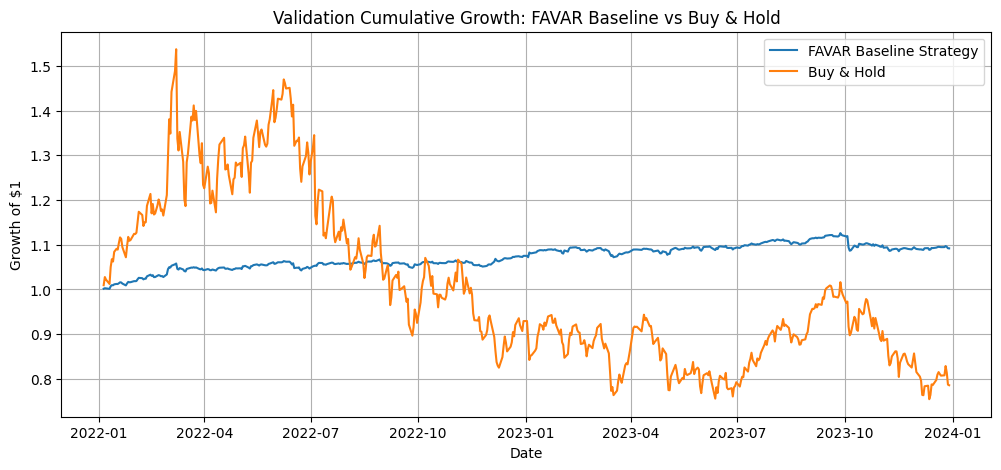

In [67]:
plot_df = favar_val_strategy.dropna(subset=["net_strategy_return"]).copy()

plot_df["cum_strategy"] = (1 + plot_df["net_strategy_return"]).cumprod()
plot_df["cum_buy_hold"] = (1 + plot_df["buy_hold_return"]).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(plot_df["Date"], plot_df["cum_strategy"], label="FAVAR Baseline Strategy")
plt.plot(plot_df["Date"], plot_df["cum_buy_hold"], label="Buy & Hold")
plt.legend()
plt.title("Validation Cumulative Growth: FAVAR Baseline vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

## 16. Probability Calibration Check

To understand whether higher FAVAR predicted probabilities correspond to stronger realized outcomes, I group validation predictions into probability buckets and compare average predicted probability, realized upward-move frequency, and average return.

In [68]:
favar_val_bucket = favar_val_preds.copy()

favar_val_bucket["bucket"] = pd.cut(favar_val_bucket["prob_up"], bins=10)

favar_bucket_stats = favar_val_bucket.groupby("bucket", observed=False).agg({
    "returns": "mean",
    "Target": "mean",
    "prob_up": "mean",
    "forecast_return": "mean"
})

favar_bucket_stats

,returns,Target,prob_up,forecast_return
bucket,,,,
"(0.231, 0.271]",-0.031189,0.333333,0.246237,-0.014888
"(0.271, 0.31]",0.020261,1.000000,0.299211,-0.014414
"(0.31, 0.35]",-0.042833,0.000000,0.339747,-0.008778
"(0.35, 0.389]",-0.013890,0.285714,0.377610,-0.006833
"(0.389, 0.428]",-0.001579,0.294118,0.416838,-0.004942
"(0.428, 0.468]",0.001974,0.451613,0.451475,-0.002867
"(0.468, 0.507]",-0.002234,0.512821,0.486381,-0.000891
"(0.507, 0.546]",0.004009,0.686441,0.521512,0.001413
"(0.546, 0.586]",0.008578,0.750000,0.561139,0.004287


# Regime-Feature FAVAR Model

This section trains a FAVAR model using the HMM regime probabilities as additional predictors. Unlike the baseline FAVAR, this version allows the latent factor state to incorporate information about the estimated market regime.

## 17. Load HMM-Augmented Modeling Files

The HMM notebook exports train, validation, and test files containing the original predictors plus the regime label and regime probability features. I load those files here before constructing the regime-feature FAVAR model.

In [69]:
train_df_2 = pd.read_csv("train_final_weighted_hmm.csv")
val_df_2 = pd.read_csv("val_final_weighted_hmm.csv")
test_df_2 = pd.read_csv("test_final_weighted_hmm.csv")

for df in [train_df_2, val_df_2, test_df_2]:
    if "macro_month" in df.columns:
        df.drop(columns=["macro_month"], inplace=True)

    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)
    df.reset_index(drop=True, inplace=True)

# align to baseline dates
train_df_2 = train_df_2[train_df_2["Date"].isin(train_df["Date"])].copy()
val_df_2 = val_df_2[val_df_2["Date"].isin(val_df["Date"])].copy()
test_df_2 = test_df_2[test_df_2["Date"].isin(test_df["Date"])].copy()

def align_returns_to_base(df_regime, df_base):
    df_regime = df_regime.drop(columns=["returns"], errors="ignore")

    out = df_regime.merge(
        df_base[["Date", "returns"]],
        on="Date",
        how="left"
    )

    return out.sort_values("Date").reset_index(drop=True)

train_df_2 = align_returns_to_base(train_df_2, train_df)
val_df_2 = align_returns_to_base(val_df_2, val_df)
test_df_2 = align_returns_to_base(test_df_2, test_df)

print(train_df_2.shape, val_df_2.shape, test_df_2.shape)

(1742, 50) (528, 50) (474, 50)


## 18. Define Regime-Feature FAVAR Inputs

This feature set includes HMM regime probability variables but excludes the hard regime label. The probabilities provide a smoother representation of regime uncertainty than a single discrete label.

In [70]:
regime_feature_exclude_cols = [
    "Date",
    "Price",
    "returns",
    "Target",
    "regime"
]

favar_feature_cols_2 = [c for c in train_df_2.columns if c not in regime_feature_exclude_cols]

print("FAVAR regime-feature feature count:", len(favar_feature_cols_2))
print("Added features:", set(favar_feature_cols_2) - set(favar_feature_cols))

FAVAR regime-feature feature count: 45
Added features: {'regime_prob_1', 'regime_prob_0', 'regime_prob_2'}


## 19. Tune the Regime-Feature FAVAR

This tuning loop repeats the baseline FAVAR search after adding HMM regime probabilities to the feature set.

In [71]:
factor_candidates = [2, 3, 4, 5, 6, 7, 8, 9, 10]
lag_candidates = [1, 2, 3, 4, 5, 6]
method_candidates = ["student_t", "normal"]
t_df_candidates = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

favar_results_2 = []

for k in factor_candidates:
    train_z_2, val_z_2, scaler_k_2, pca_k_2 = build_favar_state(
        train_df_2,
        val_df_2,
        favar_feature_cols_2,
        k
    )

    for p in lag_candidates:
        for method in method_candidates:
            df_options = [None] if method == "normal" else t_df_candidates

            for t_df_val in df_options:
                print(f"Running k={k}, p={p}, method={method}, t_df={t_df_val}")

                try:
                    val_preds_tmp_2 = rolling_var_forecast_with_probs(
                        train_z=train_z_2,
                        eval_z=val_z_2,
                        eval_meta=val_df_2,
                        p=p,
                        vol_window=20,
                        method=method,
                        t_df=5 if t_df_val is None else t_df_val
                    )

                    acc = accuracy_score(
                        val_preds_tmp_2["Target"],
                        val_preds_tmp_2["pred"]
                    )

                    try:
                        auc = roc_auc_score(
                            val_preds_tmp_2["Target"],
                            val_preds_tmp_2["prob_up"]
                        )
                    except ValueError:
                        auc = np.nan

                    favar_results_2.append({
                        "k": k,
                        "p": p,
                        "method": method,
                        "t_df": t_df_val,
                        "val_accuracy": acc,
                        "val_auc": auc,
                        "prob_mean": val_preds_tmp_2["prob_up"].mean(),
                        "prob_std": val_preds_tmp_2["prob_up"].std()
                    })

                except Exception as e:
                    print(f"Failed k={k}, p={p}, method={method}, t_df={t_df_val}: {e}")

                    favar_results_2.append({
                        "k": k,
                        "p": p,
                        "method": method,
                        "t_df": t_df_val,
                        "val_accuracy": np.nan,
                        "val_auc": np.nan,
                        "prob_mean": np.nan,
                        "prob_std": np.nan
                    })

favar_results_df_2 = pd.DataFrame(favar_results_2).sort_values(
    by="val_auc",
    ascending=False
).reset_index(drop=True)

favar_results_df_2.head(20)

Running k=2, p=1, method=student_t, t_df=1
Running k=2, p=1, method=student_t, t_df=2
Running k=2, p=1, method=student_t, t_df=3
Running k=2, p=1, method=student_t, t_df=4
Running k=2, p=1, method=student_t, t_df=5
Running k=2, p=1, method=student_t, t_df=6
Running k=2, p=1, method=student_t, t_df=7
Running k=2, p=1, method=student_t, t_df=8
Running k=2, p=1, method=student_t, t_df=9
Running k=2, p=1, method=student_t, t_df=10
Running k=2, p=1, method=normal, t_df=None
Running k=2, p=2, method=student_t, t_df=1
Running k=2, p=2, method=student_t, t_df=2
Running k=2, p=2, method=student_t, t_df=3
Running k=2, p=2, method=student_t, t_df=4
Running k=2, p=2, method=student_t, t_df=5
Running k=2, p=2, method=student_t, t_df=6
Running k=2, p=2, method=student_t, t_df=7
Running k=2, p=2, method=student_t, t_df=8
Running k=2, p=2, method=student_t, t_df=9
Running k=2, p=2, method=student_t, t_df=10
Running k=2, p=2, method=normal, t_df=None
Running k=2, p=3, method=student_t, t_df=1
Running k

,k,p,method,t_df,val_accuracy,val_auc,prob_mean,prob_std
0,3,3,student_t,2.0,0.554924,0.624222,0.475788,0.044746
1,3,3,student_t,7.0,0.554924,0.624222,0.473495,0.049348
2,3,3,normal,NaN,0.554924,0.624222,0.472472,0.051422
3,3,3,student_t,10.0,0.554924,0.624222,0.473194,0.049957
4,3,3,student_t,9.0,0.554924,0.624222,0.473272,0.049798
5,3,3,student_t,8.0,0.554924,0.624222,0.473370,0.049600
6,3,3,student_t,1.0,0.554924,0.624222,0.478345,0.039667
7,3,3,student_t,6.0,0.554924,0.624222,0.473661,0.049014
8,3,3,student_t,4.0,0.554924,0.624222,0.474226,0.047876
9,3,3,student_t,3.0,0.554924,0.624222,0.474769,0.046785


## 20. Select the Regime-Feature FAVAR Specification

The best regime-feature specification is selected using validation ROC-AUC.

In [72]:
best_row_2 = favar_results_df_2.dropna(subset=["val_auc"]).iloc[0]

best_k_2 = int(best_row_2["k"])
best_p_2 = int(best_row_2["p"])
best_method_2 = best_row_2["method"]
best_t_df_2 = 5 if pd.isna(best_row_2["t_df"]) else int(best_row_2["t_df"])

print("Best k:", best_k_2)
print("Best p:", best_p_2)
print("Best method:", best_method_2)
print("Best t_df:", best_t_df_2)

best_row_2

Best k: 3
Best p: 3
Best method: student_t
Best t_df: 2


k                       3
p                       3
method          student_t
t_df                  2.0
val_accuracy     0.554924
val_auc          0.624222
prob_mean        0.475788
prob_std         0.044746
Name: 0, dtype: object

## 21. Generate Regime-Feature FAVAR Predictions

Using the selected regime-feature FAVAR specification, I generate validation predictions with an expanding-window forecast.

In [73]:
train_z_2, val_z_2, favar_scaler_2, favar_pca_2 = build_favar_state(
    train_df_2,
    val_df_2,
    favar_feature_cols_2,
    best_k_2
)

favar_val_preds_2 = rolling_var_forecast_with_probs(
    train_z=train_z_2,
    eval_z=val_z_2,
    eval_meta=val_df_2,
    p=best_p_2,
    vol_window=20,
    method=best_method_2,
    t_df=best_t_df_2
)

favar_val_preds_2["split"] = "val"
favar_val_preds_2["model"] = "favar"
favar_val_preds_2["version"] = "regime_feature"

The training predictions are generated using a rolling in-sample procedure after an initial history window.

In [74]:
favar_train_preds_2 = rolling_var_train_predictions_with_probs(
    train_z=train_z_2,
    train_meta=train_df_2,
    p=best_p_2,
    initial_window=250,
    vol_window=20,
    method=best_method_2,
    t_df=best_t_df_2
)

favar_train_preds_2["model"] = "favar"
favar_train_preds_2["version"] = "regime_feature"

The training predictions are generated using a rolling in-sample procedure after an initial history window.

In [75]:
train_z_test_2, test_z_2, _, _ = build_favar_state(
    train_df_2,
    test_df_2,
    favar_feature_cols_2,
    best_k_2
)

favar_test_preds_2 = rolling_var_forecast_with_probs(
    train_z=train_z_test_2,
    eval_z=test_z_2,
    eval_meta=test_df_2,
    p=best_p_2,
    vol_window=20,
    method=best_method_2,
    t_df=best_t_df_2
)

favar_test_preds_2["split"] = "test"
favar_test_preds_2["model"] = "favar"
favar_test_preds_2["version"] = "regime_feature"

The regime-feature FAVAR prediction files are saved for later comparison.

In [76]:
os.makedirs("results/predictions", exist_ok=True)

favar_train_preds_2.to_csv("results/predictions/favar_regime_feature_train_predictions.csv", index=False)
favar_val_preds_2.to_csv("results/predictions/favar_regime_feature_val_predictions.csv", index=False)
favar_test_preds_2.to_csv("results/predictions/favar_regime_feature_test_predictions.csv", index=False)

The summary below checks the distribution of regime-feature FAVAR validation probabilities and forecasted returns.

In [77]:
favar_val_preds_2[["prob_up", "pred", "Target", "returns", "vol_20", "forecast_return"]].describe()

,prob_up,pred,Target,returns,vol_20,forecast_return
count,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000
mean,0.475788,0.248106,0.530303,-0.000103,0.024159,-0.001607
std,0.044746,0.432323,0.499554,0.025630,0.008671,0.003132
min,0.228411,0.000000,0.000000,-0.134360,0.008609,-0.020558
25%,0.455565,0.000000,0.000000,-0.015055,0.018637,-0.002835
50%,0.477352,0.000000,1.000000,0.001782,0.022686,-0.001456
75%,0.499641,0.000000,1.000000,0.016680,0.027254,-0.000024
max,0.631159,1.000000,1.000000,0.082612,0.055159,0.009533


The histogram below shows the validation predicted-probability distribution for the regime-feature FAVAR.

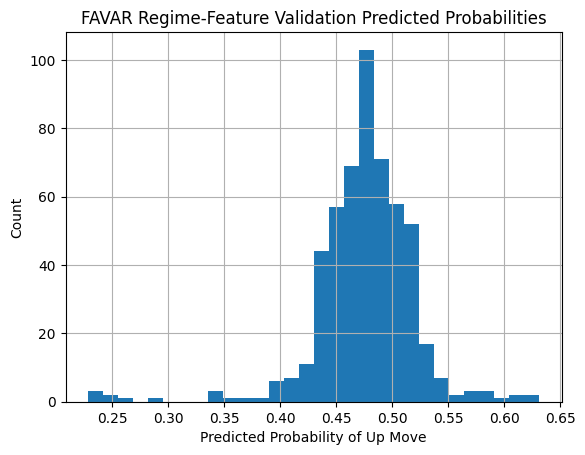

In [80]:
plt.hist(favar_val_preds_2["prob_up"], bins=30)
plt.title("FAVAR Regime-Feature Validation Predicted Probabilities")
plt.xlabel("Predicted Probability of Up Move")
plt.ylabel("Count")
plt.grid(True)
plt.show()

The validation classification metrics evaluate the regime-feature FAVAR's directional prediction performance.

In [81]:
classification_report_simple(favar_val_preds_2)

{'accuracy': 0.5549242424242424,
 'precision': 0.6717557251908397,
 'recall': 0.3142857142857143,
 'f1': 0.4282238442822384,
 'roc_auc': 0.6242223502304147,
 'confusion_matrix': array([[205,  43],
        [192,  88]], dtype=int64)}

In [82]:
classification_report_simple(favar_test_preds_2)

{'accuracy': 0.5042194092827004,
 'precision': 0.5054945054945055,
 'recall': 0.3881856540084388,
 'f1': 0.43914081145584727,
 'roc_auc': 0.5039078495255389,
 'confusion_matrix': array([[147,  90],
        [145,  92]], dtype=int64)}

The regime-feature validation predictions are converted into trading positions and compared against buy-and-hold.

In [156]:
favar_val_strategy_2 = apply_probability_vol_strategy(favar_val_preds_2)

favar_metrics_2 = pd.DataFrame({
    "FAVAR Regime-Feature Strategy Val": strategy_metrics(favar_val_strategy_2, "net_strategy_return"),
    "Buy & Hold Val": strategy_metrics(favar_val_strategy_2, "buy_hold_return")
}).T

favar_metrics_2

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
FAVAR Regime-Feature Strategy Val,0.085969,0.040225,0.039331,1.022446,-0.037567,0.082142,0.087735,0.035534
Buy & Hold Val,-0.205251,-0.103846,0.406865,-0.063716,-0.509424,1.000000,1.000000,0.000000


# Regime-Specific FAVAR Model

This section fits separate FAVAR models within each lagged HMM regime. Instead of using one global FAVAR model for all market environments, the regime-specific approach allows the latent factors and VAR dynamics to differ across regimes.

The lagged regime label is used instead of the same-day regime label to reduce look-ahead bias.

## 22. Construct Lagged Regime Labels

The regime-specific FAVAR uses the previous day's regime label. This prevents the model from using same-day regime information that would not have been available before the current day's return was realized.

In [84]:
train_df_3 = train_df_2.copy()
val_df_3 = val_df_2.copy()
test_df_3 = test_df_2.copy()

for df in [train_df_3, val_df_3, test_df_3]:
    df["regime_lag"] = df["regime"].shift(1)

train_df_3 = train_df_3.dropna(subset=["regime_lag"]).copy()
val_df_3 = val_df_3.dropna(subset=["regime_lag"]).copy()
test_df_3 = test_df_3.dropna(subset=["regime_lag"]).copy()

for df in [train_df_3, val_df_3, test_df_3]:
    df["regime_lag"] = df["regime_lag"].astype(int)
    df.sort_values("Date", inplace=True)
    df.reset_index(drop=True, inplace=True)

print("Train regimes:")
print(train_df_3["regime_lag"].value_counts())

print("\nVal regimes:")
print(val_df_3["regime_lag"].value_counts())

print("\nTest regimes:")
print(test_df_3["regime_lag"].value_counts())

Train regimes:
regime_lag
1    693
0    662
2    386
Name: count, dtype: int64

Val regimes:
regime_lag
0    324
1    161
2     42
Name: count, dtype: int64

Test regimes:
regime_lag
0    349
1    124
Name: count, dtype: int64


## 23. Define Regime-Specific FAVAR Feature Set

For the regime-specific FAVAR, the hard regime label and lagged regime label are not used as predictors. They are used only to split the data into regime-specific subsets. The HMM regime probabilities are also excluded because this version fits separate FAVAR models by regime rather than giving regime probabilities to one global model.

In [85]:
regime_specific_exclude_cols = [
    "Date",
    "Price",
    "returns",
    "Target",
    "regime",
    "regime_lag",
    "regime_prob_0",
    "regime_prob_1",
    "regime_prob_2"
]

favar_feature_cols_3 = [c for c in train_df_3.columns if c not in regime_specific_exclude_cols]

print("FAVAR regime-specific feature count:", len(favar_feature_cols_3))
print(favar_feature_cols_3)

FAVAR regime-specific feature count: 42
['RPI', 'W875RX1', 'CMRMTSPLx', 'IPFPNSS', 'USWTRADE', 'USTRADE', 'BUSLOANS', 'CONSPI', 'S&P 500', 'S&P PE ratio', 'FEDFUNDS', 'TB3MS', 'TB6MS', 'GS1', 'GS5', 'GS10', 'AAA', 'BAA', 'TB3SMFFM', 'TB6SMFFM', 'T1YFFM', 'T5YFFM', 'T10YFFM', 'AAAFFM', 'BAAFFM', 'EXSZUSx', 'EXJPUSx', 'EXUSUKx', 'EXCAUSx', 'PPICMM', 'UMCSENTx', 'net_position', 'net_position_pct', 'flow', 'long_short_ratio', 'Open_Interest_All', 'oi_change', 'vol_20', 'momentum_20', 'vol_60', 'drawdown', 'trend']


## 24. Fit One FAVAR Setup per Regime

For each lagged regime, I fit a separate scaler, PCA factor model, and FAVAR state representation using only the training observations from that regime. This allows each regime to have its own latent factor structure and VAR dynamics.

In [86]:
regime_favar_objects_3 = {}

for regime in sorted(train_df_3["regime_lag"].unique()):
    print(f"\n==============================")
    print(f"Preparing FAVAR for regime {regime}")
    print(f"==============================")

    train_r = train_df_3[train_df_3["regime_lag"] == regime].copy()

    if len(train_r) < 100:
        print(f"Warning: regime {regime} has only {len(train_r)} rows")

    train_z_r, _, scaler_r, pca_r = build_favar_state(
        train_r,
        train_r,
        favar_feature_cols_3,
        min(best_k_2, len(favar_feature_cols_3))
    )

    regime_favar_objects_3[regime] = {
        "train_df": train_r,
        "scaler": scaler_r,
        "pca": pca_r,
        "k": min(best_k_2, len(favar_feature_cols_3)),
        "p": best_p_2,
        "method": best_method_2,
        "t_df": best_t_df_2
    }


Preparing FAVAR for regime 0

Preparing FAVAR for regime 1

Preparing FAVAR for regime 2


## 25. Apply Existing Regime FAVAR Transformations

This helper applies a regime-specific scaler and PCA object to a new evaluation dataframe, then appends the realized return to produce the FAVAR state used for rolling forecasts.

In [87]:
def build_favar_state_from_existing(eval_df, feature_cols, scaler, pca):
    X_eval_scaled = scaler.transform(eval_df[feature_cols])
    eval_factors = pca.transform(X_eval_scaled)

    k = eval_factors.shape[1]
    factor_cols = [f"factor_{i}" for i in range(1, k + 1)]

    eval_factor_df = pd.DataFrame(eval_factors, columns=factor_cols)

    eval_z = pd.concat(
        [
            eval_df[["Price"]].reset_index(drop=True),
            eval_factor_df.reset_index(drop=True)
        ],
        axis=1
    )

    return eval_z

## 26. Generate Regime-Specific FAVAR Predictions

This helper applies the appropriate regime-specific FAVAR setup to each validation or test observation based on its lagged regime. Each regime's model uses its own scaler, PCA transformation, historical state, and VAR lag specification.

In [88]:
def make_regime_specific_favar_predictions(df, favar_objects, feature_cols, split_name):
    pred_list = []

    for regime, obj in favar_objects.items():
        df_r = df[df["regime_lag"] == regime].copy()
        df_r = df_r.sort_values("Date").reset_index(drop=True)

        if len(df_r) == 0:
            print(f"Skipping regime {regime} in {split_name}: no rows")
            continue

        train_r = obj["train_df"].copy().sort_values("Date").reset_index(drop=True)

        train_z_r = build_favar_state_from_existing(
            train_r,
            feature_cols,
            obj["scaler"],
            obj["pca"]
        )

        eval_z_r = build_favar_state_from_existing(
            df_r,
            feature_cols,
            obj["scaler"],
            obj["pca"]
        )

        preds_r = rolling_var_forecast_with_probs(
            train_z=train_z_r,
            eval_z=eval_z_r,
            eval_meta=df_r,
            p=obj["p"],
            vol_window=20,
            method=obj["method"],
            t_df=obj["t_df"]
        )

        preds_r["model"] = "favar"
        preds_r["version"] = "regime_specific"
        preds_r["split"] = split_name
        preds_r["regime_lag"] = regime

        pred_list.append(preds_r)

    out = pd.concat(pred_list, ignore_index=True)
    out = out.sort_values("Date").reset_index(drop=True)

    return out

The code below generates train, validation, and test predictions from the regime-specific FAVAR models.

In [89]:
favar_train_preds_3 = make_regime_specific_favar_predictions(
    train_df_3,
    regime_favar_objects_3,
    favar_feature_cols_3,
    "train"
)

favar_val_preds_3 = make_regime_specific_favar_predictions(
    val_df_3,
    regime_favar_objects_3,
    favar_feature_cols_3,
    "val"
)

favar_test_preds_3 = make_regime_specific_favar_predictions(
    test_df_3,
    regime_favar_objects_3,
    favar_feature_cols_3,
    "test"
)

print(favar_train_preds_3.shape)
print(favar_val_preds_3.shape)
print(favar_test_preds_3.shape)

Skipping regime 2 in test: no rows
(1741, 13)
(527, 13)
(473, 13)


The regime-specific FAVAR predictions are saved for later comparison and strategy evaluation.

In [90]:
favar_train_preds_3.to_csv("results/predictions/favar_regime_specific_train_predictions.csv", index=False)
favar_val_preds_3.to_csv("results/predictions/favar_regime_specific_val_predictions.csv", index=False)
favar_test_preds_3.to_csv("results/predictions/favar_regime_specific_test_predictions.csv", index=False)

The summaries below inspect predicted probabilities overall and by lagged regime.

In [91]:
favar_val_preds_3[["prob_up", "pred", "Target", "returns", "vol_20", "forecast_return", "regime_lag"]].describe()

,prob_up,pred,Target,returns,vol_20,forecast_return,regime_lag
count,527.000000,527.000000,527.000000,527.000000,527.000000,527.000000,527.000000
mean,0.468150,0.233397,0.529412,-0.000125,0.024170,-0.002746,0.464896
std,0.065305,0.423394,0.499608,0.025649,0.008675,0.008157,0.639481
min,0.126801,0.000000,0.000000,-0.134360,0.008609,-0.079491,0.000000
25%,0.439937,0.000000,0.000000,-0.015056,0.018662,-0.004294,0.000000
50%,0.468918,0.000000,1.000000,0.001678,0.022695,-0.002271,0.000000
75%,0.497101,0.000000,1.000000,0.016701,0.027295,-0.000281,1.000000
max,0.926364,1.000000,1.000000,0.082612,0.055159,0.091516,2.000000


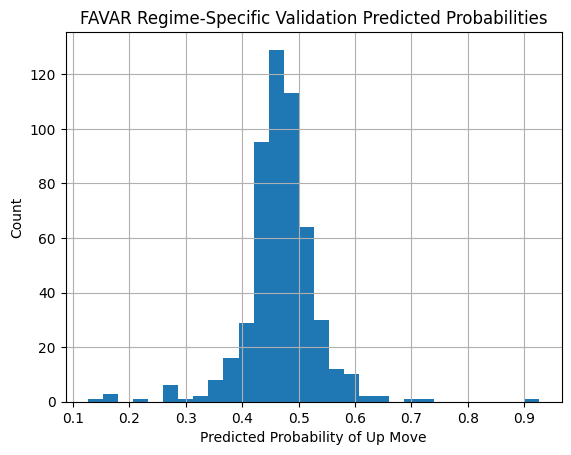

In [94]:
plt.hist(favar_val_preds_3["prob_up"], bins=30)
plt.title("FAVAR Regime-Specific Validation Predicted Probabilities")
plt.xlabel("Predicted Probability of Up Move")
plt.ylabel("Count")
plt.grid(True)
plt.show()

In [95]:
favar_val_preds_3.groupby("regime_lag")["prob_up"].describe()

,count,mean,std,min,25%,50%,75%,max
regime_lag,,,,,,,,
0,324.0,0.462730,0.055501,0.157605,0.440857,0.466730,0.489120,0.702962
1,161.0,0.474782,0.073945,0.277967,0.433191,0.477616,0.510820,0.926364
2,42.0,0.484537,0.091804,0.126801,0.458937,0.500217,0.534643,0.728154


The classification reports evaluate the regime-specific FAVAR on the validation and test periods.

In [96]:
classification_report_simple(favar_val_preds_3)

{'accuracy': 0.5180265654648957,
 'precision': 0.6016260162601627,
 'recall': 0.26523297491039427,
 'f1': 0.3681592039800995,
 'roc_auc': 0.5470285582148224,
 'confusion_matrix': array([[199,  49],
        [205,  74]], dtype=int64)}

In [97]:
classification_report_simple(favar_test_preds_3)

{'accuracy': 0.5221987315010571,
 'precision': 0.5215686274509804,
 'recall': 0.5611814345991561,
 'f1': 0.540650406504065,
 'roc_auc': 0.5276764642780519,
 'confusion_matrix': array([[114, 122],
        [104, 133]], dtype=int64)}

The regime-specific FAVAR validation predictions are converted into trading positions and compared against buy-and-hold.

In [157]:
favar_val_strategy_3 = apply_probability_vol_strategy(favar_val_preds_3)

favar_metrics_3 = pd.DataFrame({
    "FAVAR Regime-Specific Strategy Val": strategy_metrics(favar_val_strategy_3, "net_strategy_return"),
    "Buy & Hold Val": strategy_metrics(favar_val_strategy_3, "buy_hold_return")
}).T

favar_metrics_3

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
FAVAR Regime-Specific Strategy Val,0.028958,0.013771,0.040739,0.356052,-0.050230,0.073652,0.087592,0.066037
Buy & Hold Val,-0.214415,-0.108988,0.407170,-0.077489,-0.509424,1.000000,1.000000,0.000000


The table below summarizes validation trading performance across the baseline, regime-feature, and regime-specific FAVAR models.

In [158]:
favar_all_metrics = pd.concat([
    favar_metrics,
    favar_metrics_2,
    favar_metrics_3
])

favar_all_metrics

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
FAVAR Baseline Strategy Val,0.091889,0.042932,0.040655,1.054390,-0.035901,0.088477,0.094136,0.036097
Buy & Hold Val,-0.205251,-0.103846,0.406865,-0.063716,-0.509424,1.000000,1.000000,0.000000
FAVAR Regime-Feature Strategy Val,0.085969,0.040225,0.039331,1.022446,-0.037567,0.082142,0.087735,0.035534
Buy & Hold Val,-0.205251,-0.103846,0.406865,-0.063716,-0.509424,1.000000,1.000000,0.000000
FAVAR Regime-Specific Strategy Val,0.028958,0.013771,0.040739,0.356052,-0.050230,0.073652,0.087592,0.066037
Buy & Hold Val,-0.214415,-0.108988,0.407170,-0.077489,-0.509424,1.000000,1.000000,0.000000


# Pre-COT FAVAR Baseline

This section trains a FAVAR model after removing all CFTC/COT positioning variables. The purpose is to create a clean comparison between the original macro/price-based feature set and the COT-augmented models. This helps isolate whether the alternative COT dataset adds useful predictive or trading information.

## 27. Load and Align the Pre-COT Dataset

The pre-COT baseline uses the original train, validation, and test files before adding the COT-enhanced features. I align the dates to the current modeling splits so that comparisons are made on the same sample period.

In [ ]:
# FAVAR PRE-COT BASELINE
# Macro/technical features only, excluding COT features

train_df_pre = pd.read_csv("train_final.csv")
val_df_pre = pd.read_csv("val_final.csv")
test_df_pre = pd.read_csv("test_final.csv")

for df in [train_df_pre, val_df_pre, test_df_pre]:
    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)
    df.reset_index(drop=True, inplace=True)

# Align to your already-processed baseline FAVAR dfs
train_df_pre = train_df_pre[train_df_pre["Date"].isin(train_df["Date"])].copy()
val_df_pre = val_df_pre[val_df_pre["Date"].isin(val_df["Date"])].copy()
test_df_pre = test_df_pre[test_df_pre["Date"].isin(test_df["Date"])].copy()

def align_returns_to_base(df_new, df_base):
    df_new = df_new.drop(columns=["returns"], errors="ignore")

    out = df_new.merge(
        df_base[["Date", "returns"]],
        on="Date",
        how="left"
    )

    return out.sort_values("Date").reset_index(drop=True)

train_df_pre = align_returns_to_base(train_df_pre, train_df)
val_df_pre = align_returns_to_base(val_df_pre, val_df)
test_df_pre = align_returns_to_base(test_df_pre, test_df)

print(train_df_pre.shape, val_df_pre.shape, test_df_pre.shape)
print(train_df_pre["Date"].min(), train_df_pre["Date"].max())
print(val_df_pre["Date"].min(), val_df_pre["Date"].max())
print(test_df_pre["Date"].min(), test_df_pre["Date"].max())

(1742, 50) (528, 50) (474, 50)
2015-05-24 00:00:00 2021-12-31 00:00:00
2022-01-04 00:00:00 2023-12-29 00:00:00
2024-01-03 00:00:00 2025-10-31 00:00:00


## 28. Identify and Remove COT Features

To construct the pre-COT baseline, I identify columns associated with CFTC/COT positioning data and remove them from the predictor set.

In [101]:
# Identify COT-derived columns

cot_keywords = [
    "Open_Interest",
    "open_interest",
    "Producer",
    "Merchant",
    "Swap",
    "Money",
    "Other_Reportable",
    "Nonreportable",
    "long",
    "short",
    "Long",
    "Short",
    "net_position",
    "net_position_pct",
    "long_short_ratio",
    "flow",
    "oi_change"
]

cot_cols = [
    c for c in train_df_pre.columns
    if any(keyword in c for keyword in cot_keywords)
]

print("COT columns removed:")
print(cot_cols)
print("Number removed:", len(cot_cols))

COT columns removed:
['net_position', 'net_position_pct', 'flow', 'long_short_ratio', 'Open_Interest_All', 'oi_change']
Number removed: 6


## 29. Define Pre-COT FAVAR Feature Set

The pre-COT model excludes date fields, prices, realized returns, target labels, regime features, and all COT-related variables. This leaves the macroeconomic and price-derived predictors available before the alternative COT dataset was introduced.

In [102]:
# Define pre-COT FAVAR feature columns

target_col = "Target"

pre_cot_exclude_cols = [
    "Date",
    "Price",
    "returns",
    "Target",
    "regime",
    "regime_prob_0",
    "regime_prob_1",
    "regime_prob_2"
] + cot_cols

favar_feature_cols_pre = [
    c for c in train_df_pre.columns
    if c not in pre_cot_exclude_cols
]

print("Pre-COT FAVAR feature count:", len(favar_feature_cols_pre))
print(favar_feature_cols_pre)

print("\nAny COT columns left?")
print([c for c in favar_feature_cols_pre if c in cot_cols])

Pre-COT FAVAR feature count: 36
['RPI', 'W875RX1', 'CMRMTSPLx', 'IPFPNSS', 'USWTRADE', 'USTRADE', 'BUSLOANS', 'CONSPI', 'S&P 500', 'S&P PE ratio', 'FEDFUNDS', 'TB3MS', 'TB6MS', 'GS1', 'GS5', 'GS10', 'AAA', 'BAA', 'TB3SMFFM', 'TB6SMFFM', 'T1YFFM', 'T5YFFM', 'T10YFFM', 'AAAFFM', 'BAAFFM', 'EXSZUSx', 'EXJPUSx', 'EXUSUKx', 'EXCAUSx', 'PPICMM', 'UMCSENTx', 'vol_20', 'momentum_20', 'vol_60', 'drawdown', 'trend']

Any COT columns left?
[]


## 30. Tune the Pre-COT FAVAR

The pre-COT FAVAR is tuned using the same validation process as the other FAVAR versions.

In [105]:
# Tune Pre-COT FAVAR

factor_candidates = [1,2,3,4, 5,6, 7, 8, 9, 10]
lag_candidates = [1, 2, 3, 4, 5]
method_candidates = ["student_t", "normal"]
t_df_candidates = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

favar_results_pre = []

for k in factor_candidates:
    train_z_pre, val_z_pre, scaler_k_pre, pca_k_pre = build_favar_state(
        train_df_pre,
        val_df_pre,
        favar_feature_cols_pre,
        k
    )

    for p in lag_candidates:
        for method in method_candidates:

            df_options = [None] if method == "normal" else t_df_candidates

            for t_df_val in df_options:
                print(f"Running k={k}, p={p}, method={method}, t_df={t_df_val}")

                try:
                    val_preds_tmp_pre = rolling_var_forecast_with_probs(
                        train_z=train_z_pre,
                        eval_z=val_z_pre,
                        eval_meta=val_df_pre,
                        p=p,
                        vol_window=20,
                        method=method,
                        t_df=5 if t_df_val is None else t_df_val
                    )

                    acc = accuracy_score(
                        val_preds_tmp_pre["Target"],
                        val_preds_tmp_pre["pred"]
                    )

                    try:
                        auc = roc_auc_score(
                            val_preds_tmp_pre["Target"],
                            val_preds_tmp_pre["prob_up"]
                        )
                    except ValueError:
                        auc = np.nan

                    favar_results_pre.append({
                        "k": k,
                        "p": p,
                        "method": method,
                        "t_df": t_df_val,
                        "val_accuracy": acc,
                        "val_auc": auc,
                        "prob_mean": val_preds_tmp_pre["prob_up"].mean(),
                        "prob_std": val_preds_tmp_pre["prob_up"].std()
                    })

                except Exception as e:
                    print(f"Failed k={k}, p={p}, method={method}, t_df={t_df_val}: {e}")

                    favar_results_pre.append({
                        "k": k,
                        "p": p,
                        "method": method,
                        "t_df": t_df_val,
                        "val_accuracy": np.nan,
                        "val_auc": np.nan,
                        "prob_mean": np.nan,
                        "prob_std": np.nan
                    })

favar_results_df_pre = pd.DataFrame(favar_results_pre).sort_values(
    by="val_auc",
    ascending=False
).reset_index(drop=True)

favar_results_df_pre.head(20)

Running k=1, p=1, method=student_t, t_df=1
Running k=1, p=1, method=student_t, t_df=2
Running k=1, p=1, method=student_t, t_df=3
Running k=1, p=1, method=student_t, t_df=4
Running k=1, p=1, method=student_t, t_df=5
Running k=1, p=1, method=student_t, t_df=6
Running k=1, p=1, method=student_t, t_df=7
Running k=1, p=1, method=student_t, t_df=8
Running k=1, p=1, method=student_t, t_df=9
Running k=1, p=1, method=student_t, t_df=10
Running k=1, p=1, method=normal, t_df=None
Running k=1, p=2, method=student_t, t_df=1
Running k=1, p=2, method=student_t, t_df=2
Running k=1, p=2, method=student_t, t_df=3
Running k=1, p=2, method=student_t, t_df=4
Running k=1, p=2, method=student_t, t_df=5
Running k=1, p=2, method=student_t, t_df=6
Running k=1, p=2, method=student_t, t_df=7
Running k=1, p=2, method=student_t, t_df=8
Running k=1, p=2, method=student_t, t_df=9
Running k=1, p=2, method=student_t, t_df=10
Running k=1, p=2, method=normal, t_df=None
Running k=1, p=3, method=student_t, t_df=1
Running k

,k,p,method,t_df,val_accuracy,val_auc,prob_mean,prob_std
0,2,3,student_t,8.0,0.568182,0.621054,0.483327,0.051017
1,2,3,student_t,3.0,0.568182,0.621054,0.484227,0.048085
2,2,3,student_t,9.0,0.568182,0.621054,0.483264,0.051223
3,2,3,student_t,10.0,0.568182,0.621054,0.483213,0.051389
4,2,3,student_t,1.0,0.568182,0.621054,0.486518,0.040691
5,2,3,student_t,2.0,0.568182,0.621054,0.484881,0.045964
6,2,3,normal,NaN,0.568182,0.621054,0.482747,0.052917
7,2,3,student_t,4.0,0.568182,0.621054,0.483878,0.049220
8,2,3,student_t,5.0,0.568182,0.621054,0.483661,0.049926
9,2,3,student_t,6.0,0.568182,0.621054,0.483514,0.050406


## 31. Select the Pre-COT FAVAR Specification

The best pre-COT specification is selected using validation ROC-AUC.

In [106]:
# Select best Pre-COT FAVAR parameters

best_row_pre = favar_results_df_pre.dropna(subset=["val_auc"]).iloc[0]

best_k_pre = int(best_row_pre["k"])
best_p_pre = int(best_row_pre["p"])
best_method_pre = best_row_pre["method"]
best_t_df_pre = 5 if pd.isna(best_row_pre["t_df"]) else int(best_row_pre["t_df"])

print("Best Pre-COT k:", best_k_pre)
print("Best Pre-COT p:", best_p_pre)
print("Best Pre-COT method:", best_method_pre)
print("Best Pre-COT t_df:", best_t_df_pre)

best_row_pre

Best Pre-COT k: 2
Best Pre-COT p: 3
Best Pre-COT method: student_t
Best Pre-COT t_df: 8


k                       2
p                       3
method          student_t
t_df                  8.0
val_accuracy     0.568182
val_auc          0.621054
prob_mean        0.483327
prob_std         0.051017
Name: 0, dtype: object

## 32. Generate and Save Pre-COT FAVAR Predictions

Using the selected pre-COT specification, I generate train, validation, and test predictions and save them for later comparison.

In [107]:
# Build final Pre-COT FAVAR validation predictions

train_z_pre, val_z_pre, favar_scaler_pre, favar_pca_pre = build_favar_state(
    train_df_pre,
    val_df_pre,
    favar_feature_cols_pre,
    best_k_pre
)

favar_val_preds_pre = rolling_var_forecast_with_probs(
    train_z=train_z_pre,
    eval_z=val_z_pre,
    eval_meta=val_df_pre,
    p=best_p_pre,
    vol_window=20,
    method=best_method_pre,
    t_df=best_t_df_pre
)

favar_val_preds_pre["split"] = "val"
favar_val_preds_pre["model"] = "favar"
favar_val_preds_pre["version"] = "pre_cot_baseline"

In [108]:
# Build Pre-COT FAVAR train predictions

favar_train_preds_pre = rolling_var_train_predictions_with_probs(
    train_z=train_z_pre,
    train_meta=train_df_pre,
    p=best_p_pre,
    initial_window=250,
    vol_window=20,
    method=best_method_pre,
    t_df=best_t_df_pre
)

favar_train_preds_pre["model"] = "favar"
favar_train_preds_pre["version"] = "pre_cot_baseline"

In [109]:
# Build Pre-COT FAVAR test predictions

train_z_test_pre, test_z_pre, _, _ = build_favar_state(
    train_df_pre,
    test_df_pre,
    favar_feature_cols_pre,
    best_k_pre
)

favar_test_preds_pre = rolling_var_forecast_with_probs(
    train_z=train_z_test_pre,
    eval_z=test_z_pre,
    eval_meta=test_df_pre,
    p=best_p_pre,
    vol_window=20,
    method=best_method_pre,
    t_df=best_t_df_pre
)

favar_test_preds_pre["split"] = "test"
favar_test_preds_pre["model"] = "favar"
favar_test_preds_pre["version"] = "pre_cot_baseline"

In [110]:
# Save Pre-COT FAVAR predictions

os.makedirs("results/predictions", exist_ok=True)

favar_train_preds_pre.to_csv(
    "results/predictions/favar_pre_cot_baseline_train_predictions.csv",
    index=False
)

favar_val_preds_pre.to_csv(
    "results/predictions/favar_pre_cot_baseline_val_predictions.csv",
    index=False
)

favar_test_preds_pre.to_csv(
    "results/predictions/favar_pre_cot_baseline_test_predictions.csv",
    index=False
)

The summaries and histograms below check the distribution of pre-COT predicted probabilities and forecasted returns.

In [111]:
# Probability diagnostics

favar_val_preds_pre[
    ["prob_up", "pred", "Target", "returns", "vol_20", "forecast_return"]
].describe()

,prob_up,pred,Target,returns,vol_20,forecast_return
count,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000
mean,0.483327,0.325758,0.530303,-0.000103,0.024159,-0.001000
std,0.051017,0.469102,0.499554,0.025630,0.008671,0.003263
min,0.183930,0.000000,0.000000,-0.134360,0.008609,-0.022934
25%,0.464046,0.000000,0.000000,-0.015055,0.018637,-0.002161
50%,0.484926,0.000000,1.000000,0.001782,0.022686,-0.000850
75%,0.509744,1.000000,1.000000,0.016680,0.027254,0.000579
max,0.657226,1.000000,1.000000,0.082612,0.055159,0.010450


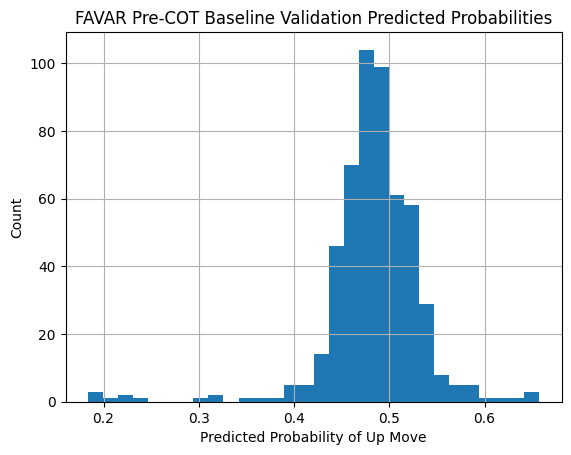

In [112]:
plt.hist(favar_val_preds_pre["prob_up"], bins=30)
plt.title("FAVAR Pre-COT Baseline Validation Predicted Probabilities")
plt.xlabel("Predicted Probability of Up Move")
plt.ylabel("Count")
plt.grid(True)
plt.show()

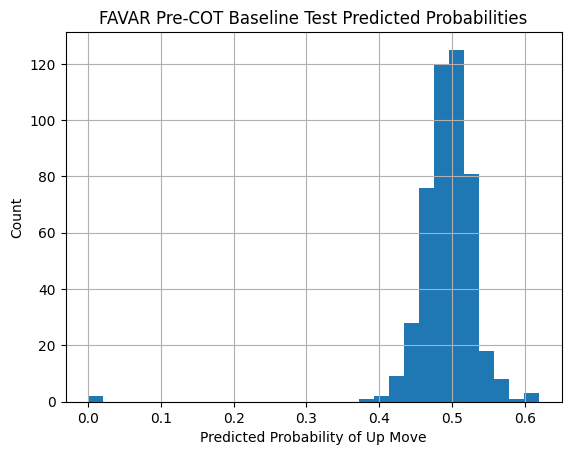

In [113]:
plt.hist(favar_test_preds_pre["prob_up"], bins=30)
plt.title("FAVAR Pre-COT Baseline Test Predicted Probabilities")
plt.xlabel("Predicted Probability of Up Move")
plt.ylabel("Count")
plt.grid(True)
plt.show()

The validation and test classification reports evaluate the pre-COT FAVAR's directional prediction performance.

In [114]:
# Classification metrics

classification_report_simple(favar_val_preds_pre)

{'accuracy': 0.5681818181818182,
 'precision': 0.6511627906976745,
 'recall': 0.4,
 'f1': 0.49557522123893805,
 'roc_auc': 0.6210541474654379,
 'confusion_matrix': array([[188,  60],
        [168, 112]], dtype=int64)}

In [115]:
classification_report_simple(favar_test_preds_pre)

{'accuracy': 0.5210970464135021,
 'precision': 0.5235849056603774,
 'recall': 0.46835443037974683,
 'f1': 0.49443207126948774,
 'roc_auc': 0.510851181256565,
 'confusion_matrix': array([[136, 101],
        [126, 111]], dtype=int64)}

The pre-COT validation predictions are converted into trading positions and compared with the other FAVAR versions.

In [159]:
# Trading metrics

favar_val_strategy_pre = apply_probability_vol_strategy(favar_val_preds_pre)

favar_metrics_pre = pd.DataFrame({
    "FAVAR Pre-COT Baseline Strategy Val": strategy_metrics(
        favar_val_strategy_pre,
        "net_strategy_return"
    ),
    "Buy & Hold Val": strategy_metrics(
        favar_val_strategy_pre,
        "buy_hold_return"
    )
}).T

favar_metrics_pre

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
FAVAR Pre-COT Baseline Strategy Val,0.104398,0.048629,0.044250,1.095329,-0.040643,0.090856,0.098217,0.038753
Buy & Hold Val,-0.205251,-0.103846,0.406865,-0.063716,-0.509424,1.000000,1.000000,0.000000


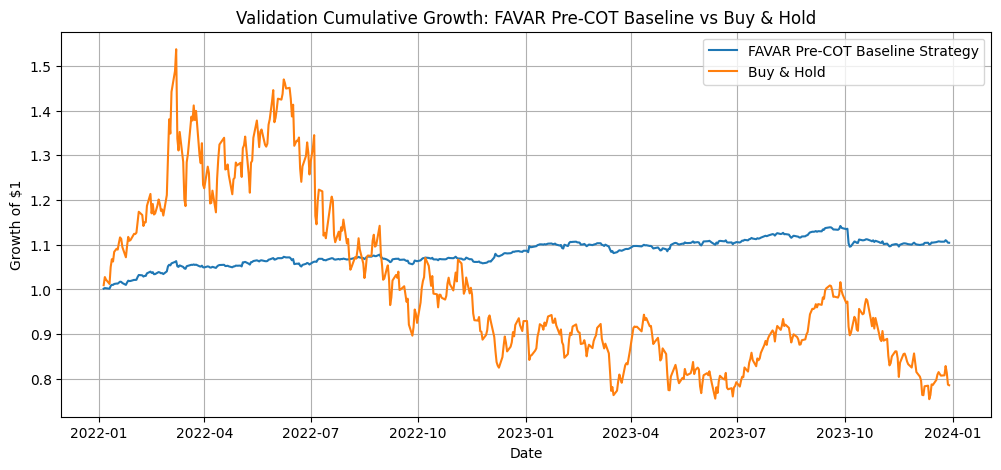

In [117]:
# Cumulative growth plot

plot_df_pre = favar_val_strategy_pre.dropna(subset=["net_strategy_return"]).copy()

plot_df_pre["cum_strategy"] = (1 + plot_df_pre["net_strategy_return"]).cumprod()
plot_df_pre["cum_buy_hold"] = (1 + plot_df_pre["buy_hold_return"]).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(
    plot_df_pre["Date"],
    plot_df_pre["cum_strategy"],
    label="FAVAR Pre-COT Baseline Strategy"
)
plt.plot(
    plot_df_pre["Date"],
    plot_df_pre["cum_buy_hold"],
    label="Buy & Hold"
)
plt.legend()
plt.title("Validation Cumulative Growth: FAVAR Pre-COT Baseline vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

In [118]:
# Bucket test

favar_val_bucket_pre = favar_val_preds_pre.copy()

favar_val_bucket_pre["bucket"] = pd.cut(
    favar_val_bucket_pre["prob_up"],
    bins=10
)

favar_bucket_stats_pre = favar_val_bucket_pre.groupby(
    "bucket",
    observed=False
).agg({
    "returns": "mean",
    "Target": "mean",
    "prob_up": "mean",
    "forecast_return": "mean"
})

favar_bucket_stats_pre

,returns,Target,prob_up,forecast_return
bucket,,,,
"(0.183, 0.231]",-0.026657,0.500000,0.201986,-0.019171
"(0.231, 0.279]",-0.006931,0.000000,0.241147,-0.011499
"(0.279, 0.326]",-0.031230,0.333333,0.312259,-0.011434
"(0.326, 0.373]",-0.025325,0.000000,0.353061,-0.010847
"(0.373, 0.421]",-0.000350,0.363636,0.402079,-0.006259
"(0.421, 0.468]",0.002326,0.430769,0.451728,-0.002833
"(0.468, 0.515]",-0.001808,0.530303,0.488841,-0.000704
"(0.515, 0.563]",0.003817,0.694737,0.529793,0.001925
"(0.563, 0.61]",0.013699,0.727273,0.578868,0.005120


In [160]:
# Optional full FAVAR comparison table after all FAVAR metrics exist

favar_all_metrics = pd.concat([
    favar_metrics_pre,
    favar_metrics,
    favar_metrics_2,
    favar_metrics_3
])

favar_all_metrics

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
FAVAR Pre-COT Baseline Strategy Val,0.104398,0.048629,0.044250,1.095329,-0.040643,0.090856,0.098217,0.038753
Buy & Hold Val,-0.205251,-0.103846,0.406865,-0.063716,-0.509424,1.000000,1.000000,0.000000
FAVAR Baseline Strategy Val,0.091889,0.042932,0.040655,1.054390,-0.035901,0.088477,0.094136,0.036097
Buy & Hold Val,-0.205251,-0.103846,0.406865,-0.063716,-0.509424,1.000000,1.000000,0.000000
FAVAR Regime-Feature Strategy Val,0.085969,0.040225,0.039331,1.022446,-0.037567,0.082142,0.087735,0.035534
Buy & Hold Val,-0.205251,-0.103846,0.406865,-0.063716,-0.509424,1.000000,1.000000,0.000000
FAVAR Regime-Specific Strategy Val,0.028958,0.013771,0.040739,0.356052,-0.050230,0.073652,0.087592,0.066037
Buy & Hold Val,-0.214415,-0.108988,0.407170,-0.077489,-0.509424,1.000000,1.000000,0.000000


# Final FAVAR Test Runs

After comparing model versions on the validation period, I perform final test evaluation. Each final FAVAR version is retrained or reconstructed using the combined train and validation data, then evaluated once on the held-out test set.

The same trading-strategy parameters are applied to all final FAVAR versions so that differences in performance come from the model predictions rather than from model-specific strategy tuning.

## 33. Define Final Tuned Trading Strategy

This function converts final predicted probabilities into trading positions. The final strategy uses the same parameter values across all FAVAR versions: a signal multiplier, probability thresholds, asymmetric long/short scaling, nonlinear signal shaping, volatility targeting, position clipping, and transaction costs.

Strategy returns use the previous day's position multiplied by the current day's realized return, which avoids look-ahead bias.

This is the optimized trading strategy. The models are retrained on train and validation sets and then evaluated on the optimal strategy.

In [120]:
final_strategy_params = {
    "signal_multiplier": 3.5,
    "long_threshold": 0.50,
    "short_threshold": 0.50,
    "alpha": 3.0,
    "beta": 1.55,
    "gamma": 0.7,
    "target_annual_vol": 0.28
}

def apply_probability_vol_strategy_tuned(
    preds,
    signal_multiplier=3.5,
    long_threshold=0.50,
    short_threshold=0.50,
    target_annual_vol=0.28,
    vol_col="vol_20",
    transaction_cost=0.0005,
    vol_floor=0.005,
    alpha=3.0,
    beta=1.55,
    gamma=0.7,
    max_position=1.0
):
    df = preds.copy()

    prob = df["prob_up"]

    raw_signal = np.zeros(len(df))

    long_mask = prob >= long_threshold
    short_mask = prob <= short_threshold

    raw_signal[long_mask] = signal_multiplier * (prob[long_mask] - long_threshold)
    raw_signal[short_mask] = signal_multiplier * (prob[short_mask] - short_threshold)

    raw_signal = np.where(
        raw_signal >= 0,
        alpha * raw_signal,
        beta * raw_signal
    )

    raw_signal = np.sign(raw_signal) * (np.abs(raw_signal) ** gamma)

    target_daily_vol = target_annual_vol / np.sqrt(252)
    adjusted_vol = df[vol_col].clip(lower=vol_floor)
    
    df["position"] = raw_signal * (target_daily_vol / adjusted_vol)
    df["position"] = df["position"].clip(-max_position, max_position)

    df["turnover"] = (df["position"] - df["position"].shift(1)).abs()

    df["gross_strategy_return"] = df["position"].shift(1) * df["returns"]
    df["net_strategy_return"] = (
        df["gross_strategy_return"] - transaction_cost * df["turnover"]
    )

    df["buy_hold_return"] = df["returns"]

    return df

## 34. Final Test Run: Pre-COT FAVAR

The pre-COT FAVAR is reconstructed using the combined train and validation period, then evaluated on the held-out test set. This represents the final performance of the macro/price feature set before adding CFTC/COT positioning data.

In [161]:
trainval_df_pre = pd.concat([train_df_pre, val_df_pre], axis=0).copy()
trainval_df_pre["Date"] = pd.to_datetime(trainval_df_pre["Date"])
test_df_pre["Date"] = pd.to_datetime(test_df_pre["Date"])

trainval_df_pre = trainval_df_pre.sort_values("Date").reset_index(drop=True)
test_df_pre = test_df_pre.sort_values("Date").reset_index(drop=True)

trainval_z_pre, test_z_pre, favar_scaler_pre_final, favar_pca_pre_final = build_favar_state(
    trainval_df_pre,
    test_df_pre,
    favar_feature_cols_pre,
    best_k_pre
)

favar_test_preds_pre_final = rolling_var_forecast_with_probs(
    train_z=trainval_z_pre,
    eval_z=test_z_pre,
    eval_meta=test_df_pre,
    p=best_p_pre,
    vol_window=20,
    method=best_method_pre,
    t_df=best_t_df_pre
)

favar_test_preds_pre_final["split"] = "test"
favar_test_preds_pre_final["model"] = "favar"
favar_test_preds_pre_final["version"] = "pre_cot_baseline_final_trainval"

favar_test_preds_pre_final.to_csv(
    "results/final_test_predictions/favar_pre_cot_baseline_final_test_predictions.csv",
    index=False
)


favar_test_strategy_pre_final = apply_probability_vol_strategy_tuned(
    favar_test_preds_pre_final,
    **final_strategy_params
)

favar_pre_final_test_metrics = pd.DataFrame({
    "FAVAR Pre-COT Final Test Strategy": strategy_metrics(
        favar_test_strategy_pre_final,
        "net_strategy_return"
    ),
    "Buy & Hold Final Test": strategy_metrics(
        favar_test_strategy_pre_final,
        "buy_hold_return"
    )
}).T

favar_pre_final_test_metrics

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
FAVAR Pre-COT Final Test Strategy,-0.045059,-0.024265,0.137937,-0.109545,-0.169813,0.303704,0.409661,0.365546
Buy & Hold Final Test,-0.206663,-0.115807,0.299283,-0.260718,-0.381141,1.000000,1.000000,0.000000


The classification report below evaluates the final pre-COT FAVAR on the held-out test set.

In [162]:
classification_report_simple(favar_test_preds_pre_final)

{'accuracy': 0.5,
 'precision': 0.5,
 'recall': 0.759493670886076,
 'f1': 0.6030150753768844,
 'roc_auc': 0.5134860866314159,
 'confusion_matrix': array([[ 57, 180],
        [ 57, 180]], dtype=int64)}

The helper below plots final test-period cumulative growth for each FAVAR strategy against buy-and-hold.

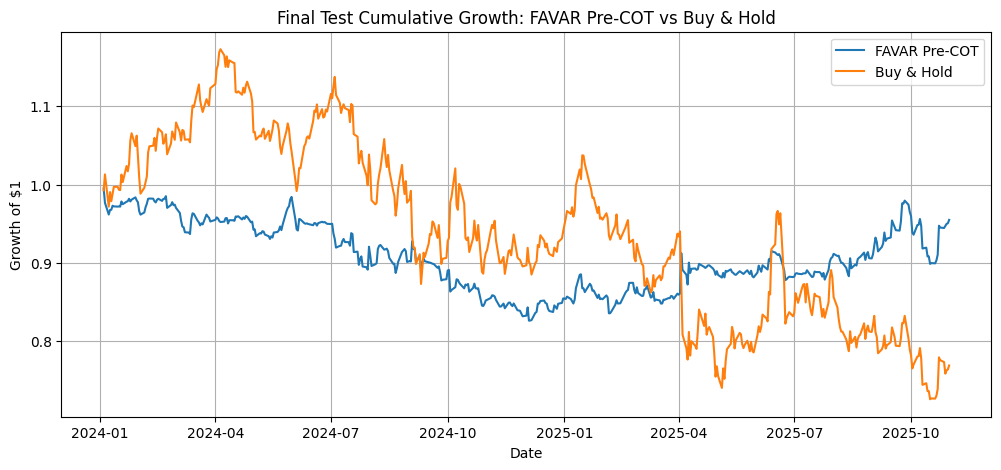

In [185]:
def plot_final_strategy_growth(strategy_df, label):
    plot_df = strategy_df.dropna(subset=["net_strategy_return"]).copy()

    plot_df["cum_strategy"] = (1 + plot_df["net_strategy_return"]).cumprod()
    plot_df["cum_buy_hold"] = (1 + plot_df["buy_hold_return"]).cumprod()

    plt.figure(figsize=(12, 5))
    plt.plot(plot_df["Date"], plot_df["cum_strategy"], label=label)
    plt.plot(plot_df["Date"], plot_df["cum_buy_hold"], label="Buy & Hold")
    plt.legend()
    plt.title(f"Final Test Cumulative Growth: {label} vs Buy & Hold")
    plt.xlabel("Date")
    plt.ylabel("Growth of $1")
    plt.grid(True)
    plt.show()

plot_final_strategy_growth(favar_test_strategy_pre_final, "FAVAR Pre-COT")

## 35. Final Test Run: COT-Augmented Baseline FAVAR

This final model uses the COT-augmented feature set but does not include HMM regime features. It is reconstructed using train plus validation data and evaluated on the held-out test set.

In [164]:
trainval_df = pd.concat([train_df, val_df], axis=0).copy()
trainval_df["Date"] = pd.to_datetime(trainval_df["Date"])
test_df["Date"] = pd.to_datetime(test_df["Date"])

trainval_df = trainval_df.sort_values("Date").reset_index(drop=True)
test_df = test_df.sort_values("Date").reset_index(drop=True)

trainval_z, test_z, favar_scaler_final, favar_pca_final = build_favar_state(
    trainval_df,
    test_df,
    favar_feature_cols,
    best_k
)

favar_test_preds_final = rolling_var_forecast_with_probs(
    train_z=trainval_z,
    eval_z=test_z,
    eval_meta=test_df,
    p=best_p,
    vol_window=20,
    method=best_method,
    t_df=best_t_df
)

favar_test_preds_final["split"] = "test"
favar_test_preds_final["model"] = "favar"
favar_test_preds_final["version"] = "baseline_final_trainval"

favar_test_preds_final.to_csv(
    "results/final_test_predictions/favar_baseline_final_test_predictions.csv",
    index=False
)


favar_test_strategy_final = apply_probability_vol_strategy_tuned(
    favar_test_preds_final,
    **final_strategy_params
)

favar_final_test_metrics = pd.DataFrame({
    "FAVAR Baseline Final Test Strategy": strategy_metrics(
        favar_test_strategy_final,
        "net_strategy_return"
    ),
    "Buy & Hold Final Test": strategy_metrics(
        favar_test_strategy_final,
        "buy_hold_return"
    )
}).T

favar_final_test_metrics

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
FAVAR Baseline Final Test Strategy,-0.087122,-0.047403,0.131896,-0.302559,-0.206085,0.29327,0.402523,0.382495
Buy & Hold Final Test,-0.206663,-0.115807,0.299283,-0.260718,-0.381141,1.00000,1.000000,0.000000


The classification report evaluates the final COT-augmented baseline FAVAR on the held-out test set.

In [134]:
classification_report_simple(favar_test_preds_final)

{'accuracy': 0.5,
 'precision': 0.5,
 'recall': 0.7383966244725738,
 'f1': 0.596252129471891,
 'roc_auc': 0.501290747565383,
 'confusion_matrix': array([[ 62, 175],
        [ 62, 175]], dtype=int64)}

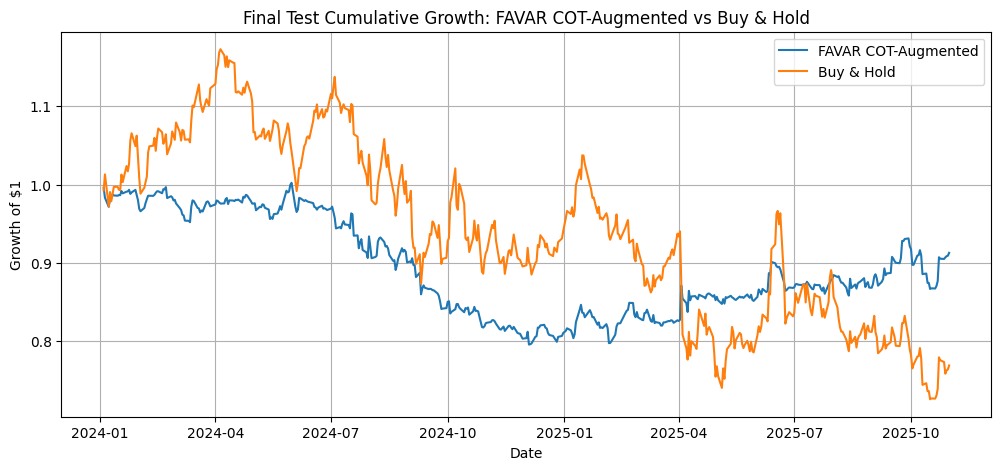

In [186]:
plot_final_strategy_growth(favar_test_strategy_final, "FAVAR COT-Augmented")

## 36. Final Test Run: Regime-Feature FAVAR

The regime-feature FAVAR uses HMM regime probabilities as additional predictors in one global FAVAR model. It is reconstructed using train plus validation data and evaluated on the held-out test set.

In [165]:
trainval_df_2 = pd.concat([train_df_2, val_df_2], axis=0).copy()
trainval_df_2["Date"] = pd.to_datetime(trainval_df_2["Date"])
test_df_2["Date"] = pd.to_datetime(test_df_2["Date"])

trainval_df_2 = trainval_df_2.sort_values("Date").reset_index(drop=True)
test_df_2 = test_df_2.sort_values("Date").reset_index(drop=True)

print("Regime prob columns used:")
print([c for c in favar_feature_cols_2 if "regime_prob" in c])

trainval_z_2, test_z_2, favar_scaler_2_final, favar_pca_2_final = build_favar_state(
    trainval_df_2,
    test_df_2,
    favar_feature_cols_2,
    best_k_2
)

favar_test_preds_2_final = rolling_var_forecast_with_probs(
    train_z=trainval_z_2,
    eval_z=test_z_2,
    eval_meta=test_df_2,
    p=best_p_2,
    vol_window=20,
    method=best_method_2,
    t_df=best_t_df_2
)

favar_test_preds_2_final["split"] = "test"
favar_test_preds_2_final["model"] = "favar"
favar_test_preds_2_final["version"] = "regime_feature_final_trainval"

favar_test_preds_2_final.to_csv(
    "results/final_test_predictions/favar_regime_feature_final_test_predictions.csv",
    index=False
)


favar_test_strategy_2_final = apply_probability_vol_strategy_tuned(
    favar_test_preds_2_final,
    **final_strategy_params
)

favar_2_final_test_metrics = pd.DataFrame({
    "FAVAR Regime-Feature Final Test Strategy": strategy_metrics(
        favar_test_strategy_2_final,
        "net_strategy_return"
    ),
    "Buy & Hold Final Test": strategy_metrics(
        favar_test_strategy_2_final,
        "buy_hold_return"
    )
}).T

favar_2_final_test_metrics

Regime prob columns used:
['regime_prob_0', 'regime_prob_1', 'regime_prob_2']


,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
FAVAR Regime-Feature Final Test Strategy,-0.022830,-0.012229,0.132175,-0.027491,-0.202325,0.295816,0.395115,0.365859
Buy & Hold Final Test,-0.206663,-0.115807,0.299283,-0.260718,-0.381141,1.000000,1.000000,0.000000


The classification report evaluates the final regime-feature FAVAR on the held-out test set.

In [140]:
classification_report_simple(favar_test_preds_2_final)

{'accuracy': 0.5,
 'precision': 0.5,
 'recall': 0.7552742616033755,
 'f1': 0.6016806722689075,
 'roc_auc': 0.5011305168331286,
 'confusion_matrix': array([[ 58, 179],
        [ 58, 179]], dtype=int64)}

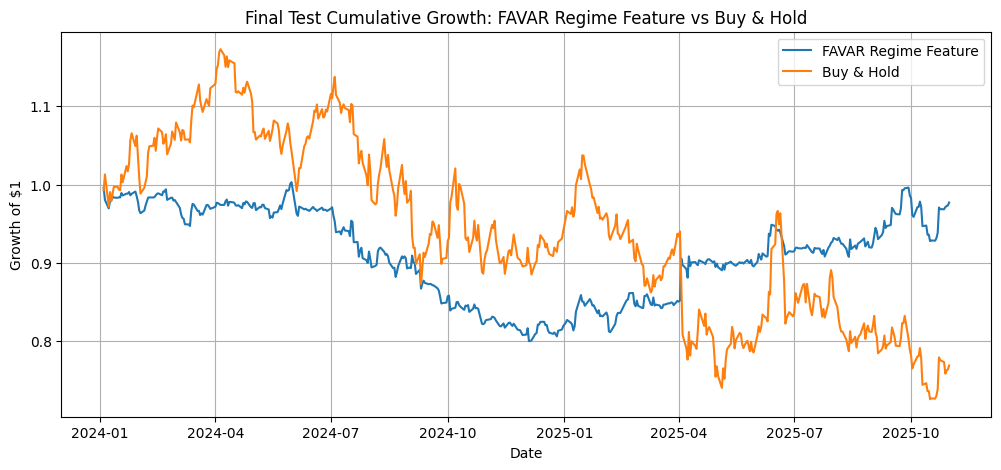

In [187]:
plot_final_strategy_growth(favar_test_strategy_2_final, "FAVAR Regime Feature")

## 37. Final Test Run: Regime-Specific FAVAR

The regime-specific FAVAR fits separate factor and VAR structures within each lagged HMM regime using the combined train and validation data. Final test predictions are generated by applying the FAVAR setup corresponding to each observation's lagged regime.

The code below combines train and validation for the final regime-specific FAVAR and verifies the lagged-regime distribution.

In [142]:
trainval_df_3 = pd.concat([train_df_3, val_df_3], axis=0).copy()
trainval_df_3["Date"] = pd.to_datetime(trainval_df_3["Date"])
test_df_3["Date"] = pd.to_datetime(test_df_3["Date"])

trainval_df_3 = trainval_df_3.sort_values("Date").reset_index(drop=True)
test_df_3 = test_df_3.sort_values("Date").reset_index(drop=True)

print("Train+Val regimes:")
print(trainval_df_3["regime_lag"].value_counts())

print("\nTest regimes:")
print(test_df_3["regime_lag"].value_counts())

print("\nRegime prob columns in FAVAR phase 3:")
print([c for c in favar_feature_cols_3 if "regime_prob" in c])

Train+Val regimes:
regime_lag
0    986
1    854
2    428
Name: count, dtype: int64

Test regimes:
regime_lag
0    349
1    124
Name: count, dtype: int64

Regime prob columns in FAVAR phase 3:
[]


For each lagged regime, I fit a final scaler, PCA factor model, and FAVAR state representation using the combined train-validation observations from that regime.

In [143]:
regime_favar_objects_final = {}

for regime in sorted(trainval_df_3["regime_lag"].unique()):
    print(f"\nPreparing final FAVAR for regime {regime}")

    trainval_r = trainval_df_3[trainval_df_3["regime_lag"] == regime].copy()
    trainval_r = trainval_r.sort_values("Date").reset_index(drop=True)

    print("Rows:", len(trainval_r))

    k_r = min(best_k_2, len(favar_feature_cols_3))

    train_z_r, _, scaler_r, pca_r = build_favar_state(
        trainval_r,
        trainval_r,
        favar_feature_cols_3,
        k_r
    )

    regime_favar_objects_final[regime] = {
        "train_df": trainval_r,
        "scaler": scaler_r,
        "pca": pca_r,
        "k": k_r,
        "p": best_p_2,
        "method": best_method_2,
        "t_df": best_t_df_2
    }


Preparing final FAVAR for regime 0
Rows: 986

Preparing final FAVAR for regime 1
Rows: 854

Preparing final FAVAR for regime 2
Rows: 428


The helper below is repeated here so the final regime-specific section can run independently if needed.

In [146]:
def build_favar_state_from_existing(eval_df, feature_cols, scaler, pca):
    X_eval_scaled = scaler.transform(eval_df[feature_cols])
    eval_factors = pca.transform(X_eval_scaled)

    k = eval_factors.shape[1]
    factor_cols = [f"factor_{i}" for i in range(1, k + 1)]

    eval_factor_df = pd.DataFrame(eval_factors, columns=factor_cols)

    eval_z = pd.concat(
        [
            eval_df[["Price"]].reset_index(drop=True),
            eval_factor_df.reset_index(drop=True)
        ],
        axis=1
    )

    return eval_z

def make_regime_specific_favar_predictions_final(
    df,
    favar_objects,
    feature_cols,
    split_name="test"
):
    pred_list = []

    for regime, obj in favar_objects.items():
        df_r = df[df["regime_lag"] == regime].copy()
        df_r = df_r.sort_values("Date").reset_index(drop=True)

        if len(df_r) == 0:
            print(f"Skipping regime {regime}: no rows")
            continue

        train_r = obj["train_df"].copy().sort_values("Date").reset_index(drop=True)

        train_z_r = build_favar_state_from_existing(
            train_r,
            feature_cols,
            obj["scaler"],
            obj["pca"]
        )

        eval_z_r = build_favar_state_from_existing(
            df_r,
            feature_cols,
            obj["scaler"],
            obj["pca"]
        )

        preds_r = rolling_var_forecast_with_probs(
            train_z=train_z_r,
            eval_z=eval_z_r,
            eval_meta=df_r,
            p=obj["p"],
            vol_window=20,
            method=obj["method"],
            t_df=obj["t_df"]
        )

        preds_r["model"] = "favar"
        preds_r["version"] = "regime_specific_final_trainval"
        preds_r["split"] = split_name
        preds_r["regime_lag"] = regime

        pred_list.append(preds_r)

    out = pd.concat(pred_list, ignore_index=True)
    out = out.sort_values("Date").reset_index(drop=True)

    return out

The final regime-specific FAVAR predictions are generated, saved, converted into trading positions, and evaluated using the common final trading rule.

In [166]:
favar_test_preds_3_final = make_regime_specific_favar_predictions_final(
    test_df_3,
    regime_favar_objects_final,
    favar_feature_cols_3,
    split_name="test"
)

favar_test_preds_3_final.to_csv(
    "results/final_test_predictions/favar_regime_specific_final_test_predictions.csv",
    index=False
)


favar_test_strategy_3_final = apply_probability_vol_strategy_tuned(
    favar_test_preds_3_final,
    **final_strategy_params
)

favar_3_final_test_metrics = pd.DataFrame({
    "FAVAR Regime-Specific Final Test Strategy": strategy_metrics(
        favar_test_strategy_3_final,
        "net_strategy_return"
    ),
    "Buy & Hold Final Test": strategy_metrics(
        favar_test_strategy_3_final,
        "buy_hold_return"
    )
}).T

favar_3_final_test_metrics

Skipping regime 2: no rows


,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
FAVAR Regime-Specific Final Test Strategy,0.237130,0.120315,0.170222,0.752428,-0.132863,0.377801,0.577224,0.454926
Buy & Hold Final Test,-0.230993,-0.130585,0.298687,-0.318223,-0.381141,1.000000,1.000000,0.000000


The classification report evaluates the final regime-specific FAVAR on the held-out test set.

In [148]:
classification_report_simple(favar_test_preds_3_final)


{'accuracy': 0.5200845665961945,
 'precision': 0.514367816091954,
 'recall': 0.7552742616033755,
 'f1': 0.611965811965812,
 'roc_auc': 0.5362940713723807,
 'confusion_matrix': array([[ 67, 169],
        [ 58, 179]], dtype=int64)}

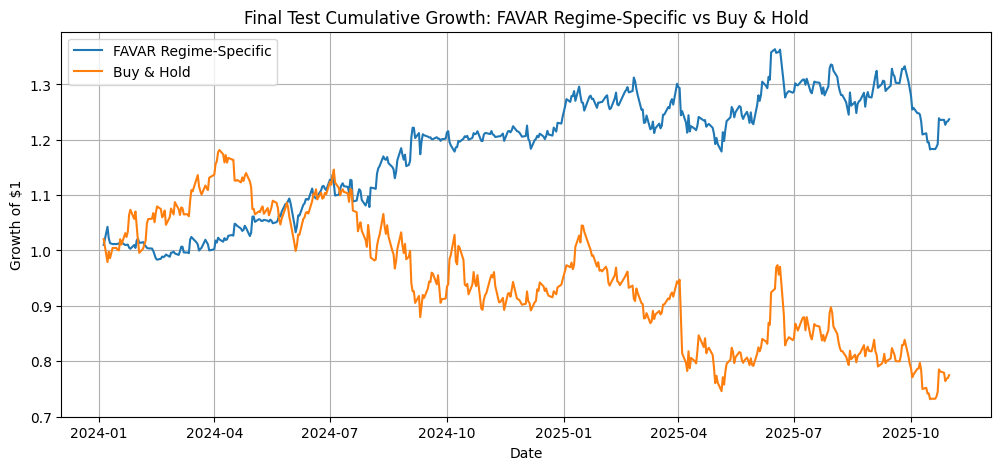

In [188]:
plot_final_strategy_growth(favar_test_strategy_3_final, "FAVAR Regime-Specific")

## 38. Final FAVAR Comparison

The table below combines final test-period strategy metrics for all FAVAR versions: pre-COT, COT-augmented baseline, regime-feature, and regime-specific.

In [167]:
favar_final_test_all_metrics = pd.concat([
    favar_pre_final_test_metrics,
    favar_final_test_metrics,
    favar_2_final_test_metrics,
    favar_3_final_test_metrics
])

favar_final_test_all_metrics

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
FAVAR Pre-COT Final Test Strategy,-0.045059,-0.024265,0.137937,-0.109545,-0.169813,0.303704,0.409661,0.365546
Buy & Hold Final Test,-0.206663,-0.115807,0.299283,-0.260718,-0.381141,1.000000,1.000000,0.000000
FAVAR Baseline Final Test Strategy,-0.087122,-0.047403,0.131896,-0.302559,-0.206085,0.293270,0.402523,0.382495
Buy & Hold Final Test,-0.206663,-0.115807,0.299283,-0.260718,-0.381141,1.000000,1.000000,0.000000
FAVAR Regime-Feature Final Test Strategy,-0.022830,-0.012229,0.132175,-0.027491,-0.202325,0.295816,0.395115,0.365859
Buy & Hold Final Test,-0.206663,-0.115807,0.299283,-0.260718,-0.381141,1.000000,1.000000,0.000000
FAVAR Regime-Specific Final Test Strategy,0.237130,0.120315,0.170222,0.752428,-0.132863,0.377801,0.577224,0.454926
Buy & Hold Final Test,-0.230993,-0.130585,0.298687,-0.318223,-0.381141,1.000000,1.000000,0.000000


The final FAVAR metrics are saved so they can be used in the paper and compared with the other model families.

In [168]:
favar_final_test_all_metrics.to_csv(
    "results/final_test_predictions/favar_final_test_metrics.csv"
)